<a href="https://colab.research.google.com/github/Rizkyard17/Geospatial-House-Price-Analysis-and-Regression-Modeling/blob/main/Predict_Pakistan_House_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Understanding

Harga properti dipengaruhi oleh banyak faktor seperti lokasi, luas bangunan, jumlah kamar, dan jenis properti. Project ini bertujuan membangun model machine learning berbasis linear regression dari scratch untuk memprediksi harga properti di Pakistan serta mengidentifikasi faktor-faktor yang paling mempengaruhi harga properti.

# Import Library

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns
import numpy as np
from google.colab import drive
from IPython.display import Markdown, display
from sklearn.model_selection import train_test_split

# Import Dataset

Dataset diperoleh dari kaggle: https://www.kaggle.com/datasets/sarcasmos/pakistan-house-prices-and-property-listings

In [149]:
# Drive Connect
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [150]:
path = '/content/drive/MyDrive/Dataset/Pakistan House Prices and Property Listings.csv'
df = pd.read_csv(path)
print("Dataste berhasil dimuat")

Dataste berhasil dimuat


# Data Understanding

## Cek Tipe Data

In [151]:
# cek variabel data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  object 
 3   property_type  168446 non-null  object 
 4   price          168446 non-null  int64  
 5   location       168446 non-null  object 
 6   city           168446 non-null  object 
 7   province_name  168446 non-null  object 
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  object 
 12  purpose        168446 non-null  object 
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  object 
 15  agency         124375 non-null  object 
 16  agent          124374 non-null  object 
dtypes: float64(2), int64(5), obje

In [152]:
df.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,2/4/2019,NaN,NaN
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,5/4/2019,NaN,NaN
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,7/17/2019,NaN,NaN
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,4/5/2019,NaN,NaN
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,7/10/2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director


Dataset memiliki 17 variabel (kolom) dengan 168446 baris (rows), diantaranya:

*   **property_id** (int64) : ID unik properti
*   **location_id** (int64) : ID Lokasi
*   **page_url** (object) : url halaman properti
*   **property_type** (object) : Jenis Properti (kategorikal)
*   **price** (int64) : Harga Properti (Rupee Pakistan)
*   **location** (object) : Nama Lokasi
*   **city** (object) : Nama Kota
*   **province_name** (object) : Nama Provinsi
*   **latitude** (float64) : Garis Lintang
*   **longitude** (float64) : Garis Bujur
*   **baths** (int64) : Jumlah Kamar Mandi
*   **area** (object) : Luas Property
*   **purpose** (object) : Tujuan (sale atau rent)
*   **bedrooms** (int64) : Jumlah Kamar Tidur
*   **date_added** (object) : Tanggal Properti ditambahkan
*   **agency** (object) : Nama Agensi Properti
*   **agent** (object) : Nama Agen Properti











## Penyesuaian Tipe Data

In [153]:
# ubah kolom date_added menjadi bentuk datetime
df['date_added'] = pd.to_datetime(df['date_added'])

satuan dalam kolom 'areas' mengikuti satuan di negara pakistan (contoh: 4 marla, 2 kanal, dll). Oleh karena itu, akan dikonversi menjadi satuan persegi agar mudah dimengerti.

1 marla = 272.25 sqft
1 kanal = 20 marla
1 sq ft = 1 sq ft

In [154]:
# Fungsi konversi ke square feet
def convert_area_to_sqft(area_str):
    if pd.isna(area_str):
        return None

    area_str = str(area_str).lower().strip()

    # Ekstrak angka dan satuan
    match = re.search(r'([\d\.]+)\s*(\w+)', area_str)
    if not match:
        return None

    value = float(match.group(1))
    unit = match.group(2)

    # Konversi berdasarkan satuan
    if unit in ['marla', 'marla']:
        return value * 272.25
    elif unit in ['kanal']:
        return value * 5445
    elif unit in ['sqft', 'sq ft', 'square feet', 'sq.ft']:
        return value
    elif unit in ['sqyd', 'sq yd', 'square yard', 'yard']:
        return value * 9
    else:
        return None  # satuan tidak dikenal

In [155]:
# Ubah kolom areas menjadi satuan persegi
df['area_sqft'] = df['area'].apply(convert_area_to_sqft)
print(df[['area', 'area_sqft']].head(10))

        area  area_sqft
0    4 Marla    1089.00
1  5.6 Marla    1524.60
2    8 Marla    2178.00
3    2 Kanal   10890.00
4    8 Marla    2178.00
5  1.6 Kanal    8712.00
6    1 Kanal    5445.00
7  6.2 Marla    1687.95
8    1 Kanal    5445.00
9    1 Kanal    5445.00


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   property_id    168446 non-null  int64         
 1   location_id    168446 non-null  int64         
 2   page_url       168446 non-null  object        
 3   property_type  168446 non-null  object        
 4   price          168446 non-null  int64         
 5   location       168446 non-null  object        
 6   city           168446 non-null  object        
 7   province_name  168446 non-null  object        
 8   latitude       168446 non-null  float64       
 9   longitude      168446 non-null  float64       
 10  baths          168446 non-null  int64         
 11  area           168446 non-null  object        
 12  purpose        168446 non-null  object        
 13  bedrooms       168446 non-null  int64         
 14  date_added     168446 non-null  datetime64[ns]
 15  

In [157]:
# Drop kolom yang tidak penting
df.drop(columns=['area', 'agency', 'agent'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   property_id    168446 non-null  int64         
 1   location_id    168446 non-null  int64         
 2   page_url       168446 non-null  object        
 3   property_type  168446 non-null  object        
 4   price          168446 non-null  int64         
 5   location       168446 non-null  object        
 6   city           168446 non-null  object        
 7   province_name  168446 non-null  object        
 8   latitude       168446 non-null  float64       
 9   longitude      168446 non-null  float64       
 10  baths          168446 non-null  int64         
 11  purpose        168446 non-null  object        
 12  bedrooms       168446 non-null  int64         
 13  date_added     168446 non-null  datetime64[ns]
 14  area_sqft      168446 non-null  float64       
dtype

## Cek Missing Value

In [158]:
# Cek Missing Value
df.isna().sum()

,0
property_id,0
location_id,0
page_url,0
property_type,0
price,0
location,0
city,0
province_name,0
latitude,0
longitude,0


## Cek Duplikasi Data

In [159]:
# Cek Duplikasi Data
print("jumlah redudansi data: ",df.duplicated().sum())

jumlah redudansi data:  0


## Cek Kategori Properti

### Berdasarkan Tipe

In [160]:
df['property_type'].value_counts()

,count
property_type,
House,105468
Flat,38238
Upper Portion,13774
Lower Portion,9229
Room,685
Farm House,657
Penthouse,395


### Berdasarkan Kota

In [161]:
# Cek berapa jumlah kategori kota
df.value_counts(df['city'])

,count
city,
Karachi,60484
Lahore,41427
Islamabad,37426
Rawalpindi,20976
Faisalabad,8133


Berdasarkan data yang digunakan, jumlah kategori kota dalam data adalah:


1.   Karachi : 60484
2.   Lahore : 41427
3.   Islamabad : 37426
4.   Rawalpindi : 20976
5.   Faisalabad : 8133

Dalam data, kota yang mendominasi adalah Karachi dengan jumlah sebesar 60484

### Berdasarkan Provinsi

In [162]:
# Cek berapa jumlah kategori provinsi
df.value_counts(df['province_name'])

,count
province_name,
Punjab,70536
Sindh,60484
Islamabad Capital,37426


Pada bagian provinsi, urutan yang diperoleh adalah sebagai berikut:


1.   Punjab : 70536
2.   Sindh : 60484
3.   Islamabad Capital : 37426

Berikut adalah banyak kota dalam setiap provinsi:

* Punjab (Lahore, Rawalpindi, Faisalabad)
* Sindh (Karachi)
* Islamabad Capital (Islamabad)

Secara jumlah, provinsi Punjab menjadi yang paling banyak, namun perlu disadari bahwa hasil tersebut diperoleh dari 3 kota yang berbeda. Sedangkan jumlah pada provinsi Sindh dan provinsi Islamabad Capital hanya diperoleh dari 1 kota saja. Sehingga secara rasio, provinsi sindh menjadi yang paling banyak property yang dijual.

### Berdasarkan Harga

In [163]:
# Cek berapa harga yang paling banyak dipatok pada penjualan properti
df['price'].value_counts().head(5)

,count
price,
15000000,2589
35000,2522
6500000,2415
8500000,2154
12500000,2117


Dari hasil tersebut, diperoleh bahwa harga yang paling banyak ditetapkan/dipatok oleh penjual property adalah sebesar 15000000, dengan total jumlah 2589 property diharga yang sama.  

### Berdasarkan Purpose

In [164]:
# Cek berapa jumlah kategori purpose
df.value_counts(df['purpose'])

,count
purpose,
For Sale,120655
For Rent,47791


Terdapat 120655 properti yang mau dijual. Sedangkan 47791 properti yang mau disewakan.

# Exploratory Data Analysis (EDA)

## Penjualan vs Penyewaan (Sale vs Rent)

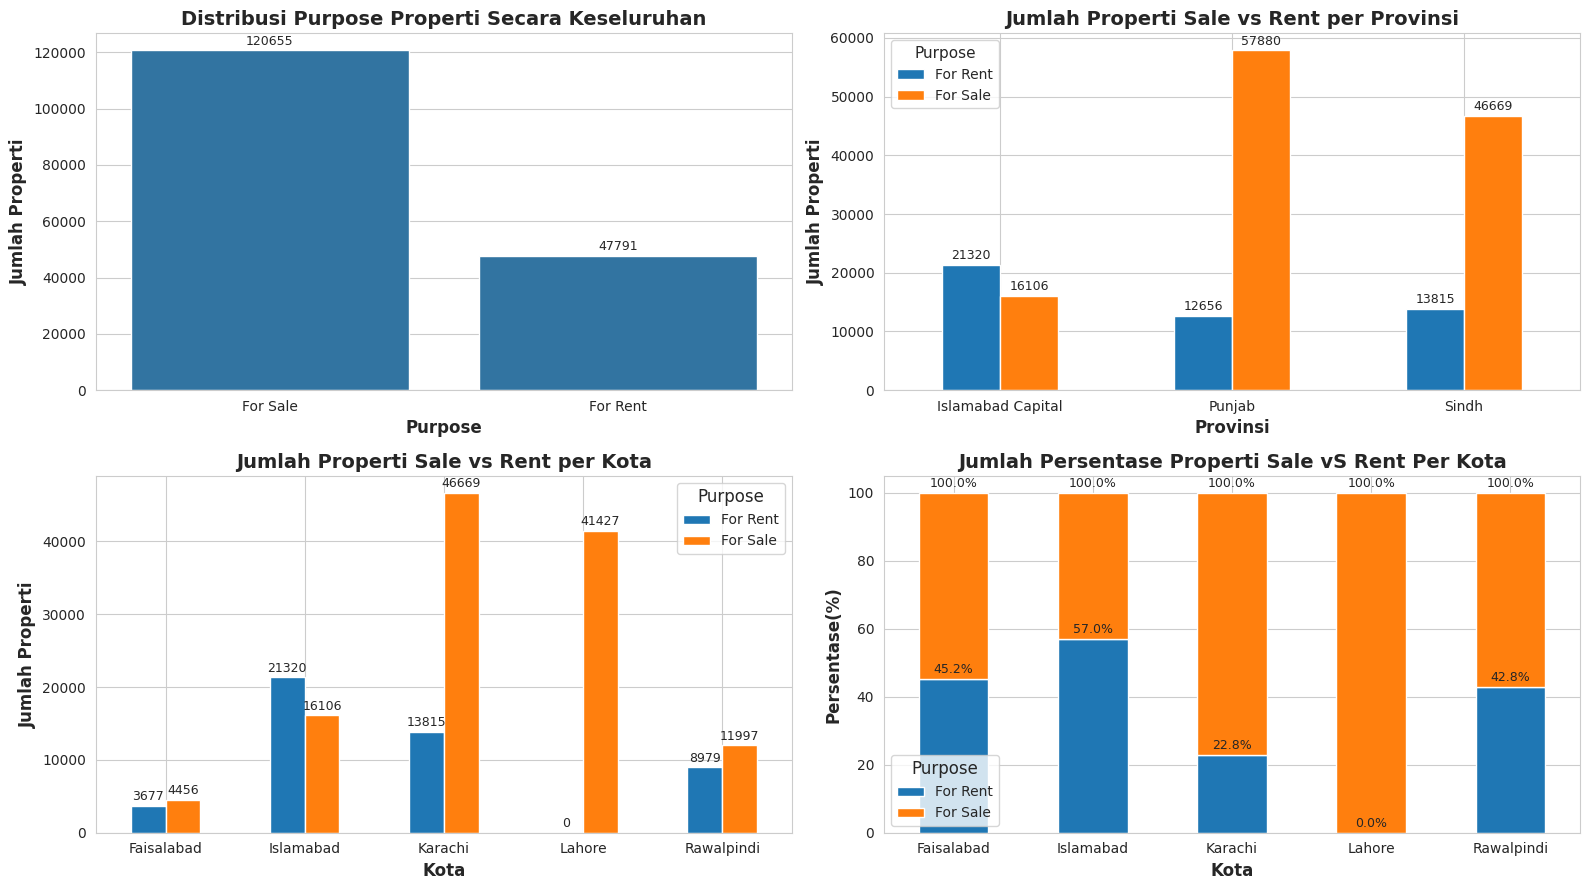

In [165]:
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (16, 9)



# GRAFIK DISTRIBUSI PURPOSE SECARA KESELURUHAN
fig, axes = plt.subplots(nrows = 2,  ncols=2, figsize=(16, 9))

purpose_counts = df['purpose'].value_counts() #Ambil banyak nilai perkategori

sns.barplot(x=purpose_counts.index, y=purpose_counts.values, ax=axes[0, 0])

axes[0, 0].set_title('Distribusi Purpose Properti Secara Keseluruhan', fontsize=14, fontweight='bold')

axes[0, 0].set_xlabel('Purpose', fontsize=12, fontweight='bold')

axes[0, 0].set_ylabel('Jumlah Properti', fontsize=12, fontweight='bold')
# Tambahkan label nilai di atas batang
for container in axes[0, 0].containers:

    axes[0, 0].bar_label(container, fmt='%d', fontsize=9, padding=2)


# GRAFIK PURPOSE PER PROVINSI
province_purpose = pd.crosstab(df['province_name'], df['purpose'])

province_purpose.plot(kind='bar', stacked=False, ax=axes[0, 1], color=['#1f77b4', '#ff7f0e'])

axes[0, 1].set_title('Jumlah Properti Sale vs Rent per Provinsi', fontsize=14, fontweight='bold')

axes[0, 1].set_xlabel('Provinsi', fontsize=12, fontweight='bold')

axes[0, 1].set_ylabel('Jumlah Properti', fontsize=12, fontweight='bold')

axes[0, 1].legend(title='Purpose', title_fontsize=11)

axes[0, 1].tick_params(axis='x', rotation=0)

# Tambahkan label nilai di atas batang
for container_province in axes[0, 1].containers:

    axes[0, 1].bar_label(container_province, fmt='%d', fontsize=9, padding=2)



# GRAFIK PURPOSE PER KOTA
city_purpose = pd.crosstab(df['city'], df['purpose'])

city_purpose.plot(kind='bar', stacked=False, ax=axes[1, 0])

axes[1, 0].set_title('Jumlah Properti Sale vs Rent per Kota', fontsize=14, fontweight='bold')

axes[1, 0].set_xlabel('Kota', fontsize=12, fontweight='bold')

axes[1, 0].set_ylabel('Jumlah Properti', fontsize=12, fontweight='bold')

axes[1, 0].legend(title='Purpose', title_fontsize=12)

axes[1, 0].tick_params(axis='x', rotation=0)

#Taambahkan label nilai di batang
for container_city in axes[1, 0].containers:

  axes[1, 0].bar_label(container_city, fmt='%d', fontsize=9, padding=2)


#GRAFIK PROPORSI DISTRIBUSI SALES DAN RENT PERKOTA
city_proporsi = city_purpose.div(city_purpose.sum(axis=1), axis=0) * 100

city_proporsi.plot(kind='bar', stacked=True, ax=axes[1, 1])

axes[1, 1].set_title('Jumlah Persentase Properti Sale vS Rent Per Kota', fontsize=14, fontweight='bold')

axes[1, 1].set_xlabel('Kota', fontsize=12, fontweight='bold')

axes[1, 1].set_ylabel('Persentase(%)', fontsize=12, fontweight='bold')

axes[1, 1].legend(title='Purpose', title_fontsize=12)

axes[1, 1].tick_params(axis='x', rotation=0)

#Tambahkan label nilai pada batang
for container_percent in axes[1, 1].containers:

  axes[1, 1].bar_label(container_percent, fmt='%.1f%%', fontsize=9, padding=2)


plt.tight_layout()

plt.show()

 TABEL DATA: JUMLAH KATEGORI PROPERTI PER PROVINSI
property_type      Farm House   Flat  House  Lower Portion  Penthouse  Room  Upper Portion
province_name                                                                             
Islamabad Capital         240   7114  19912           4250         49   377           5484
Punjab                    343   4123  60297           2298         27   177           3271
Sindh                      74  27001  25259           2681        319   131           5019


 TABEL DATA: JUMLAH KATEGORI PROPERTI PER KOTA
property_type  Farm House   Flat  House  Lower Portion  Penthouse  Room  Upper Portion
city                                                                                  
Faisalabad              5     46   6760            433          2    97            790
Islamabad             240   7114  19912           4250         49   377           5484
Karachi                74  27001  25259           2681        319   131           5019
Lahore    

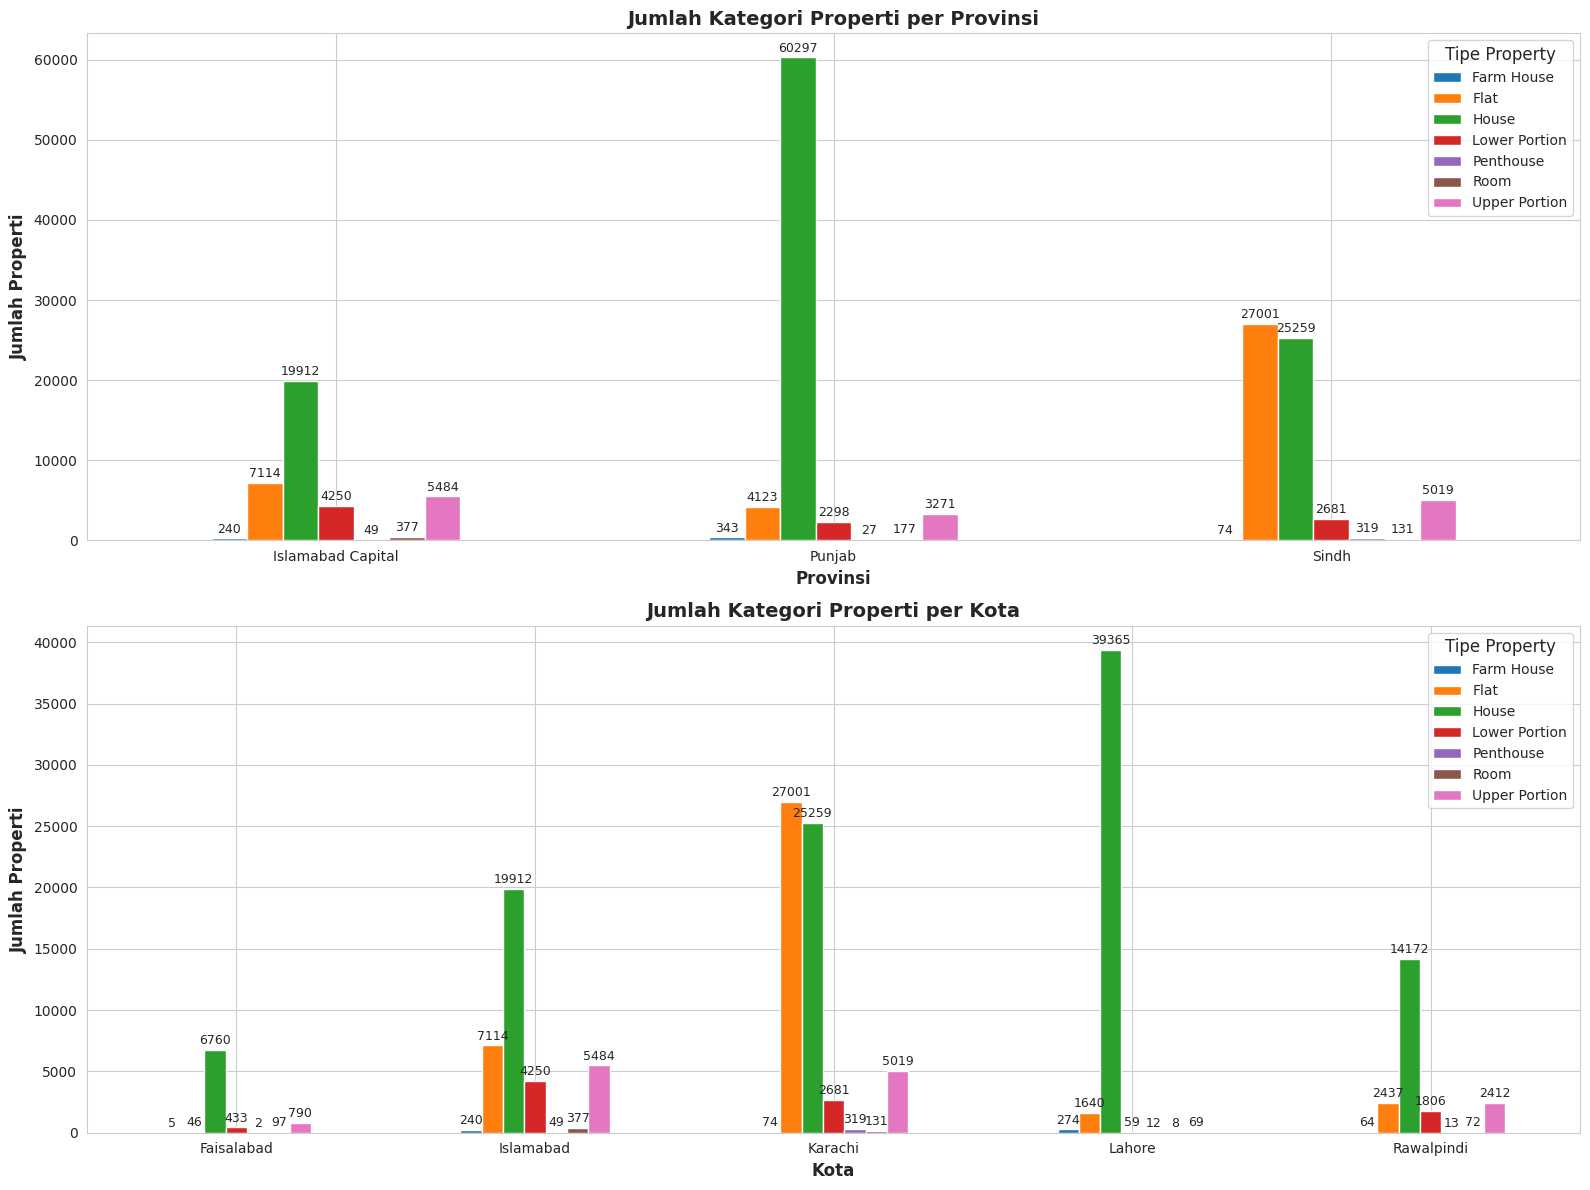

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 9)

# 1. PROSES & CETAK DATA TEKS

# Buat tabel silang (crosstab) untuk Provinsi
province_property_type = pd.crosstab(df['province_name'], df['property_type'])

print("="*60)
print(" TABEL DATA: JUMLAH KATEGORI PROPERTI PER PROVINSI")
print("="*60)
# .to_string() membuat tampilan tabel teks menjadi rapi dan lurus
print(province_property_type.to_string())
print("\n" + "="*60 + "\n")


# Buat tabel silang (crosstab) untuk Kota
city_property_type = pd.crosstab(df['city'], df['property_type'])

print("="*60)
print(" TABEL DATA: JUMLAH KATEGORI PROPERTI PER KOTA")
print("="*60)
print(city_property_type.to_string())
print("="*60 + "\n")






# 2. PROSES PEMBUATAN GRAFIK (VISUALISASI)

# Membuat kanvas tumpuk vertikal (2 baris, 1 kolom)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 12)) # Tinggi dinaikkan ke 12 agar tidak terlalu rapat

# --- GRAFIK 1: PROVINSI ---
province_property_type.plot(kind='bar', stacked=False, ax=axes[0])
axes[0].set_title('Jumlah Kategori Properti per Provinsi', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Provinsi', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Properti', fontsize=12, fontweight='bold')
axes[0].legend(title='Tipe Property', title_fontsize=12)
axes[0].tick_params(axis='x', rotation=0) # Diubah ke 45 agar nama provinsi yang panjang terbaca

for container_province in axes[0].containers:
    axes[0].bar_label(container_province, fmt='%d', fontsize=9, padding=2)


# --- GRAFIK 2: KOTA ---
city_property_type.plot(kind='bar', stacked=False, ax=axes[1])
axes[1].set_title('Jumlah Kategori Properti per Kota', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kota', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Properti', fontsize=12, fontweight='bold')
axes[1].legend(title='Tipe Property', title_fontsize=12)
axes[1].tick_params(axis='x', rotation=0) # Diubah ke 45 agar nama kota tidak tumpang tindih

for container_city in axes[1].containers:
    axes[1].bar_label(container_city, fmt='%d', fontsize=9, padding=2)

# Perbaikan: Tambahkan tanda kurung () di plt.show agar grafik tereksekusi dengan benar
plt.tight_layout()
plt.show()

### Insight Analisis Purpose: Sale vs Rent

## 1. Perbandingan Antar Provinsi

Provinsi Punjab memiliki jumlah properti tertinggi secara absolut yaitu sebanyak 70.536 properti. Namun, angka ini berasal dari 3 kota berbeda (Lahore, Rawalpindi, Faisalabad). Sementara itu, provinsi Sindh dan Islamabad Capital masing-masing hanya diwakili oleh satu kota, yaitu Karachi (60.484 properti) dan Islamabad (37.426 properti).Jika dihitung rata-rata per kota, Sindh justru menjadi provinsi dengan kepadatan properti tertinggi, yaitu 60.484 properti per kota, disusul oleh Islamabad dengan 37.426 properti per kota, dan Punjab hanya 23.512 properti per kota.


---

## 2. Proporsi Sale vs Rent per Provinsi

Dari sisi tujuan properti, ditemukan perbedaan yang sangat mencolok antar provinsi:

| Provinsi | Sale | Rent | Dominasi |
|----------|------|------|-----------|
| Punjab | 57.880 (82%) | 12.656 (18%) | Sale sangat dominan |
| Sindh | 46.669 (77%) | 13.815 (23%) | Sale dominan |
| Islamabad Capital | 16.106 (43%) | 21.320 (57%) | Rent lebih dominan |

**Insight utama:** Islamabad adalah satu-satunya wilayah di mana properti sewa (Rent) justru lebih banyak dibandingkan properti yang dijual (Sale). Hal ini berbeda dengan Punjab dan Sindh yang didominasi oleh transaksi jual beli.

- Jika fokus pada penjualan properti, targetkan pasar di Punjab dan Sindh.
- Jika fokus pada bisnis penyewaan, Islamabad adalah pasar yang paling potensial.

---

## 3. Distribusi per Kota

Ketika diurai per kota, ditemukan pola yang lebih detail:

| Kota | Sale | Rent | Provinsi |
|------|------|------|----------|
| Lahore | 41.427 | 0 | Punjab |
| Karachi | 46.669 | 13.815 | Sindh |
| Islamabad | 16.106 | 21.320 | Islamabad |
| Rawalpindi | 11.997 | 8.979 | Punjab |
| Faisalabad | 4.456 | 3.677 | Punjab |

**Temuan penting:** Kota Lahore mencatatkan angka 0 untuk properti sewa. Ini sangat tidak wajar mengingat Lahore adalah kota metropolitan terbesar di Punjab.

---

## 4. Kesimpulan

**Kesimpulan Akhir:**  
Pasar properti di Pakistan memiliki karakteristik yang serupa antar wilayah. Namun perbedaan terjadi pada kota Islamabad dimana didominasi oleh properti yang disewakan lebih banyak dibanding yang dijual. Sedangkan kota lahore didominasi oleh penjulana properti, sementara Sindh dan Punjab didominasi jual beli.

## Harga

/tmp/ipykernel_794/1115614253.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=harga_rata_rata_per_provinsi, x='province_name', y='price', ax=axes[0, 1], palette='plasma')
/tmp/ipykernel_794/1115614253.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=harga_rata_rata_per_kota, x='city', y='price', ax=axes[1, 0], palette='inferno')


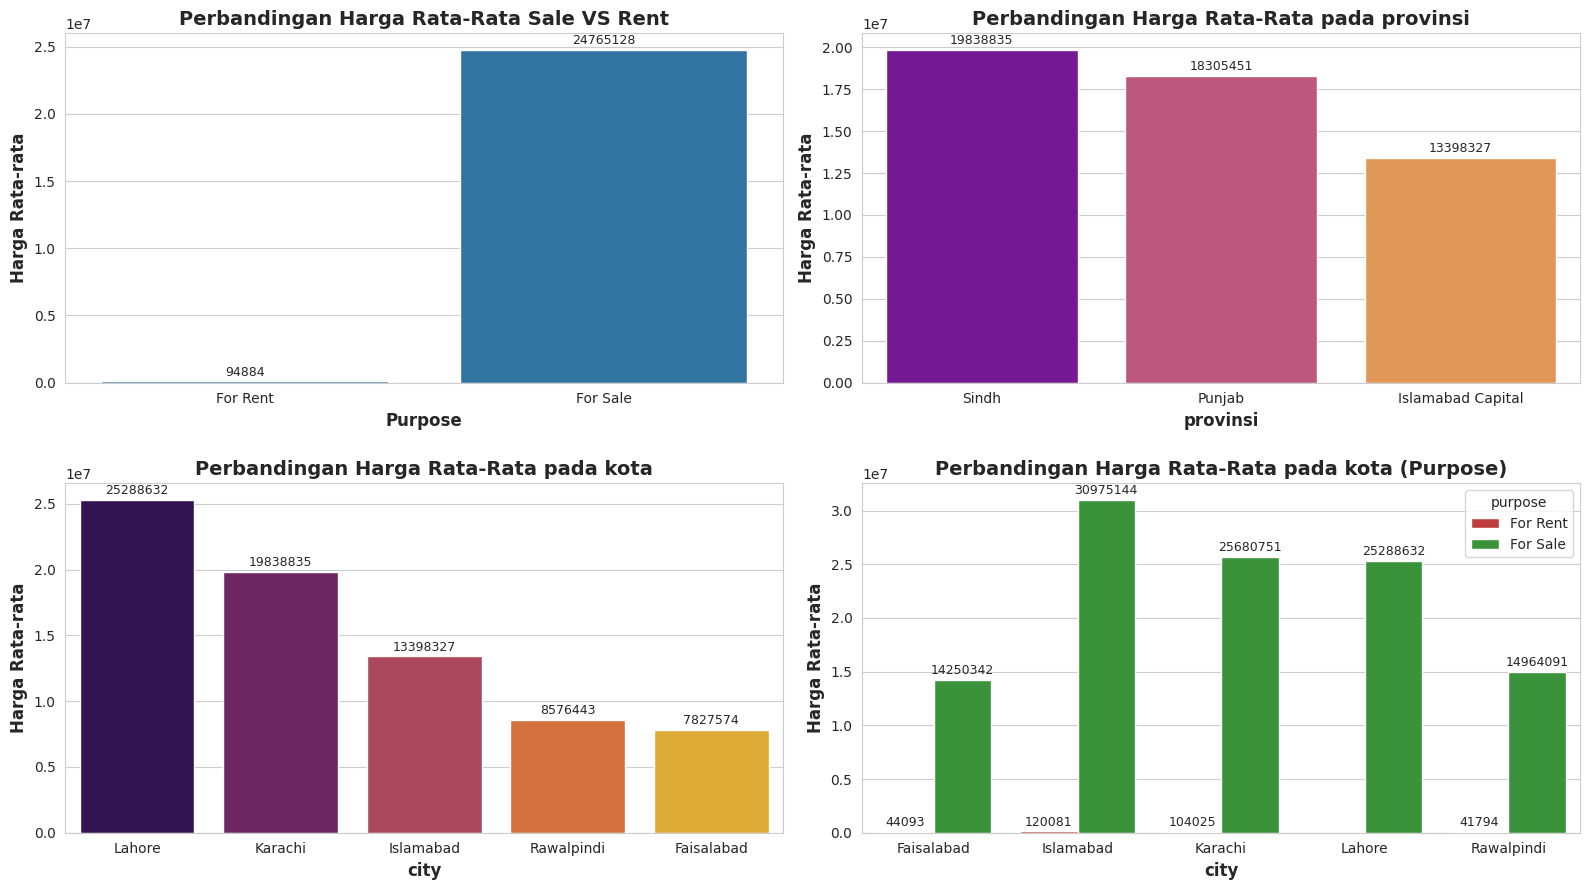

In [167]:
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (16, 9)



# GRAFIK DISTRIBUSI HARGA
fig, axes = plt.subplots(nrows = 2,  ncols=2, figsize=(16, 9))

mean_by_purpose = df.groupby('purpose')['price'].mean().round(0).reset_index() # Hitung harga rata-rata harga per purpose

sns.barplot(data=mean_by_purpose, x='purpose', y='price', ax=axes[0, 0])

axes[0, 0].set_title('Perbandingan Harga Rata-Rata Sale VS Rent', fontsize=14, fontweight='bold')

axes[0, 0].set_xlabel('Purpose', fontsize=12, fontweight='bold')

axes[0, 0].set_ylabel('Harga Rata-rata', fontsize=12, fontweight='bold')
# Tambahkan label nilai di atas batang
for container in axes[0, 0].containers:

    axes[0, 0].bar_label(container, fmt='%d', fontsize=9, padding=2)





# GRAFIK HARGA BERDASARKAN PROVINSI
harga_rata_rata_per_provinsi = df.groupby('province_name')['price'].mean().sort_values(ascending=False).round(0).reset_index()

sns.barplot(data=harga_rata_rata_per_provinsi, x='province_name', y='price', ax=axes[0, 1], palette='plasma')

axes[0, 1].set_title('Perbandingan Harga Rata-Rata pada provinsi', fontsize=14, fontweight='bold')

axes[0, 1].set_xlabel('provinsi', fontsize=12, fontweight='bold')

axes[0, 1].set_ylabel('Harga Rata-rata', fontsize=12, fontweight='bold')
# Tambahkan label nilai di atas batang
for container_harga_ratarata_kota in axes[0, 1].containers:

    axes[0, 1].bar_label(container_harga_ratarata_kota, fmt='%d', fontsize=9, padding=2)




# GRAFIK HARGA BERDASARKAN KOTA
harga_rata_rata_per_kota = df.groupby('city')['price'].mean().sort_values(ascending=False).round(0).reset_index()

sns.barplot(data=harga_rata_rata_per_kota, x='city', y='price', ax=axes[1, 0], palette='inferno')

axes[1, 0].set_title('Perbandingan Harga Rata-Rata pada kota', fontsize=14, fontweight='bold')

axes[1, 0].set_xlabel('city', fontsize=12, fontweight='bold')

axes[1, 0].set_ylabel('Harga Rata-rata', fontsize=12, fontweight='bold')
# Tambahkan label nilai di atas batang
for container_harga_ratarata_kota in axes[1, 0].containers:

    axes[1, 0].bar_label(container_harga_ratarata_kota, fmt='%d', fontsize=9, padding=2)





# GRAFIK HARGA KOTA BERDASARKAN PURPOSE
harga_rata_rata_kota_purpose = df.groupby(['city', 'purpose'])['price'].mean().round(0).reset_index()
pivot_city_purpose = harga_rata_rata_kota_purpose.pivot(index='city', columns='purpose', values='price').round(0)


sns.barplot(data=harga_rata_rata_kota_purpose, x='city', y='price', ax=axes[1, 1], hue="purpose", palette={'For Sale': '#2ca02c', 'For Rent': '#d62728'})

axes[1, 1].set_title('Perbandingan Harga Rata-Rata pada kota (Purpose)', fontsize=14, fontweight='bold')

axes[1, 1].set_xlabel('city', fontsize=12, fontweight='bold')

axes[1, 1].set_ylabel('Harga Rata-rata', fontsize=12, fontweight='bold')
# Tambahkan label nilai di atas batang
for container_harga_ratarata_kota in axes[1, 1].containers:

    axes[1, 1].bar_label(container_harga_ratarata_kota, fmt='%d', fontsize=9, padding=2)



plt.tight_layout()
plt.show()

In [168]:
# Statistik Harga berdasarkan purpose
price_stats = df.groupby('purpose')['price'].agg(['mean', 'median', 'min', 'max']).round(0)

price_stats.columns = ['Rata-Rata', 'Median', 'Minimum', 'Maksimum']

display(price_stats)


# Statistik per provinsi dan purpose
province_purpose_stats = df.groupby(['province_name', 'purpose'])['price'].agg(['mean', 'count']).round(0)

province_purpose_stats['mean_juta'] = (province_purpose_stats['mean'] / 1_000_000).round(0)

display(province_purpose_stats)

,Rata-Rata,Median,Minimum,Maksimum
purpose,,,,
For Rent,94884.0,45000.0,0,12500000
For Sale,24765128.0,13500000.0,0,2000000000


mean  count  mean_juta
province_name     purpose                               
Islamabad Capital For Rent    120081.0  21320        0.0
                  For Sale  30975144.0  16106       31.0
Punjab            For Rent     42462.0  12656        0.0
                  For Sale  22298823.0  57880       22.0
Sindh             For Rent    104025.0  13815        0.0
                  For Sale  25680751.0  46669       26.0

## Correlation

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   property_id    168446 non-null  int64         
 1   location_id    168446 non-null  int64         
 2   page_url       168446 non-null  object        
 3   property_type  168446 non-null  object        
 4   price          168446 non-null  int64         
 5   location       168446 non-null  object        
 6   city           168446 non-null  object        
 7   province_name  168446 non-null  object        
 8   latitude       168446 non-null  float64       
 9   longitude      168446 non-null  float64       
 10  baths          168446 non-null  int64         
 11  purpose        168446 non-null  object        
 12  bedrooms       168446 non-null  int64         
 13  date_added     168446 non-null  datetime64[ns]
 14  area_sqft      168446 non-null  float64       
dtype

In [170]:
# ANALISIS KORELASI ANTAR VARIABEL NUMERIK

# Identifikasi variabel numerik yang relevan
numeric_cols = ['price', 'bedrooms', 'baths', 'latitude', 'longitude', 'area_sqft']


# Filter hanya kolom yang ada di dataset
available_cols = [col for col in numeric_cols if col in df.columns]

df_numeric = df[available_cols].copy()


# Cek statistik deskriptif
df_numeric.describe().round(2)

,price,bedrooms,baths,latitude,longitude,area_sqft
count,1.684460e+05,168446.00,168446.00,168446.00,168446.00,168446.00
mean,1.776576e+07,3.18,2.87,29.86,71.24,3320.73
std,3.531003e+07,1.97,2.46,3.81,3.13,28215.76
min,0.000000e+00,0.00,0.00,11.05,25.91,0.00
25%,1.750000e+05,2.00,0.00,24.95,67.13,1306.80
50%,8.500000e+06,3.00,3.00,31.46,73.06,1932.98
75%,1.950000e+07,4.00,4.00,33.56,73.26,3267.00
max,2.000000e+09,68.00,403.00,73.18,80.16,4356000.00


=== JUMLAH OUTLIER SEBELUM FILTER (DATA ASLI) ===
- price: 13547 outlier (8.0%)
- bedrooms: 3319 outlier (2.0%)
- baths: 22 outlier (0.0%)
- area_sqft: 9773 outlier (5.8%)

=== JUMLAH OUTLIER SESUDAH CAPPING (df_no_outliers) ===
- price: 0 outlier (0.0%)
- bedrooms: 0 outlier (0.0%)
- baths: 0 outlier (0.0%)
- area_sqft: 0 outlier (0.0%)


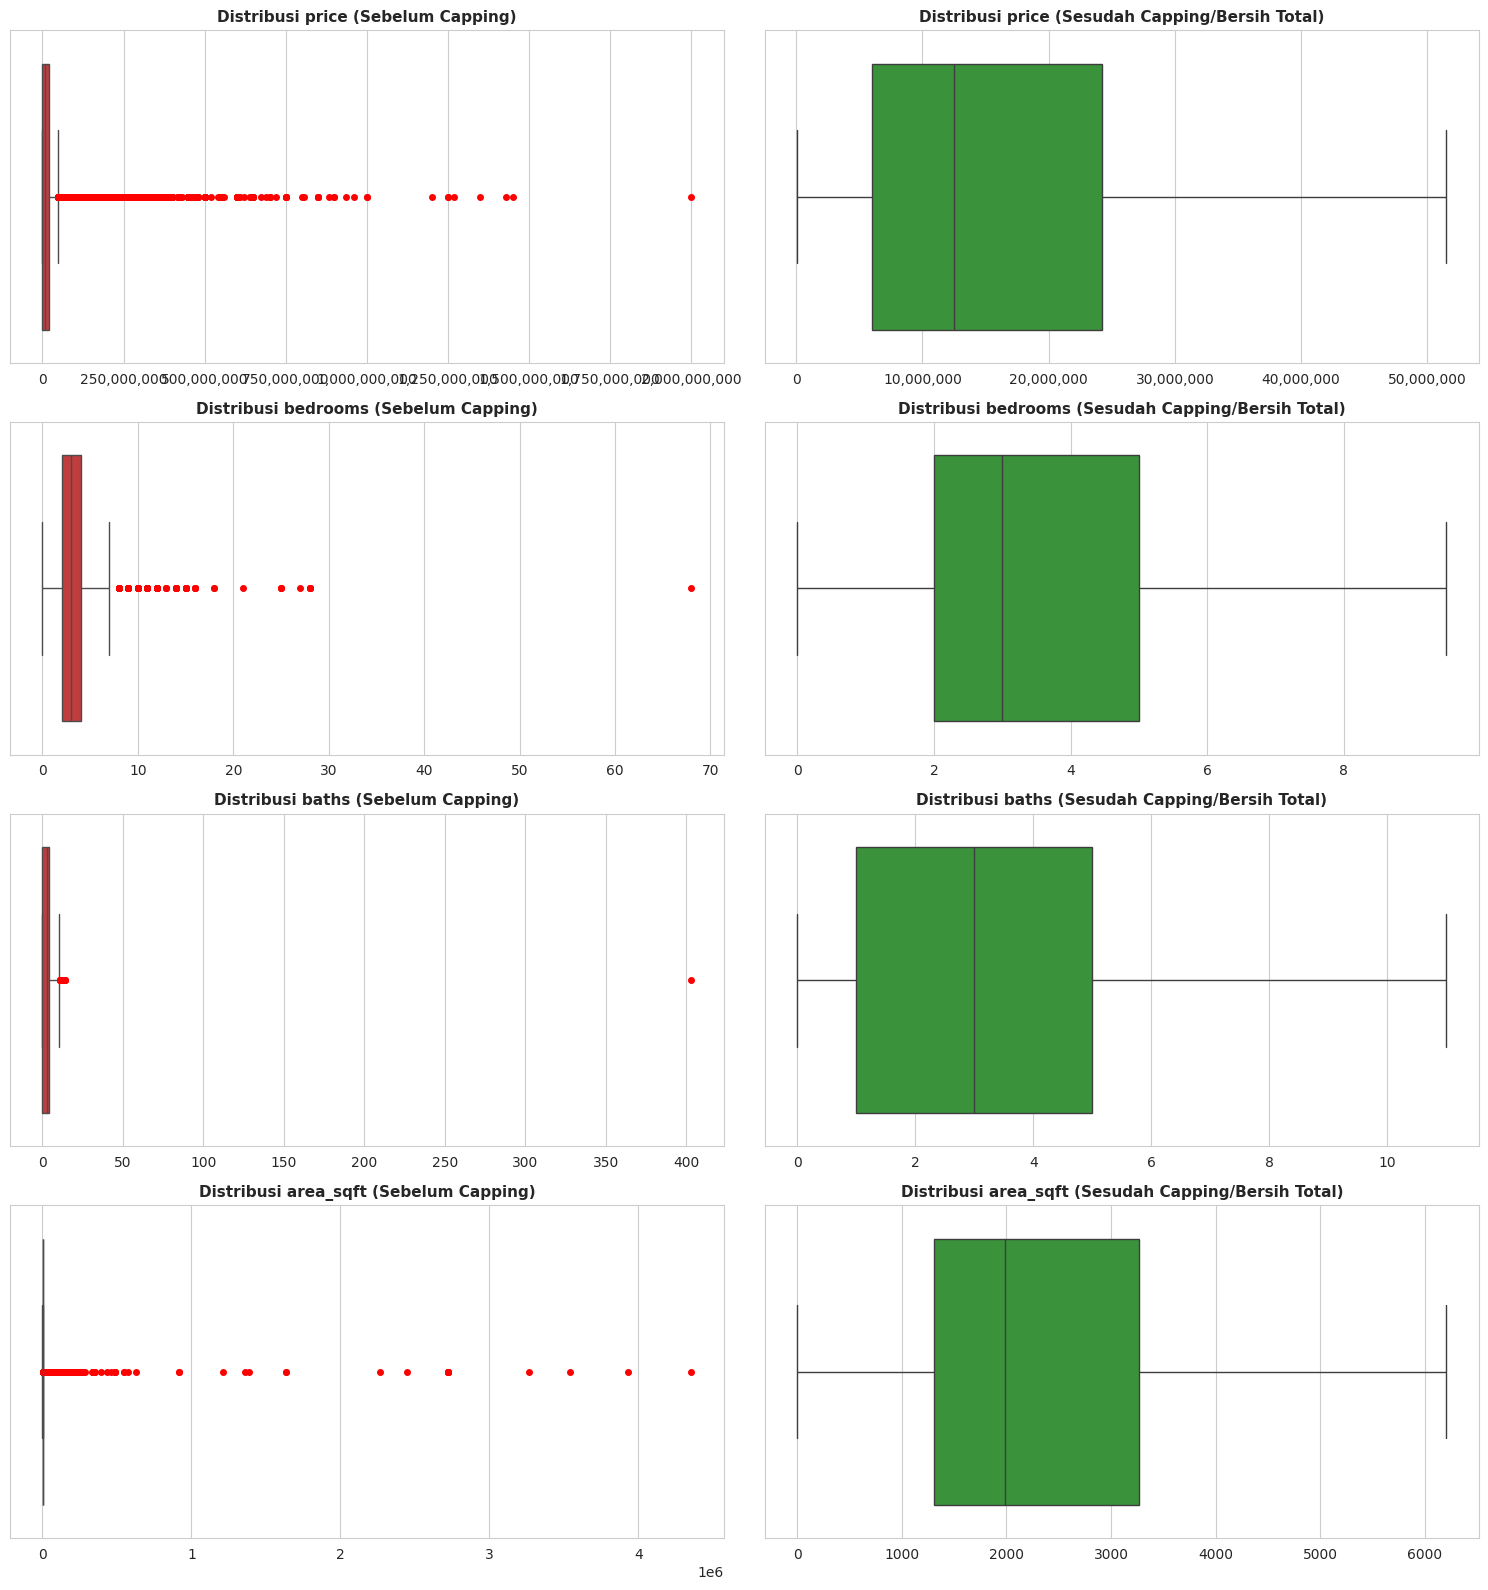

In [171]:
# =========================================================================
# 1. DETEKSI OUTLIER (SEBELUM)
# =========================================================================
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("=== JUMLAH OUTLIER SEBELUM FILTER (DATA ASLI) ===")
for col in df_numeric.columns:
    if col not in ['latitude', 'longitude']:
        n_outliers, lb, ub = detect_outliers_iqr(df_numeric, col)
        print(f"- {col}: {n_outliers} outlier ({n_outliers/len(df_numeric)*100:.1f}%)")

# Filter awal untuk membuang baris data yang rusak ekstrem (misal harga di bawah 100rb atau di atas 1 Miliar)
price_outliers = df_numeric[(df_numeric['price'] < 100000) | (df_numeric['price'] > 1_000_000_000)]
df_no_outliers = df_numeric[~df_numeric.index.isin(price_outliers.index)].copy()

# =========================================================================
# 2. PENANGANAN OUTLIER MENGGUNAKAN CAPPING (WINSORIZATION)
# =========================================================================
# Kita terapkan capping ke seluruh variabel fitur numerik utama
plot_cols = ['price', 'bedrooms', 'baths', 'area_sqft']

for col in plot_cols:
    # Ambil nilai batas atas (ub) dan batas bawah (lb) dari fungsi IQR
    _, lb, ub = detect_outliers_iqr(df_no_outliers, col)

    # Nilai yang melewati batas atas dipaksa turun menjadi senilai batas atas.
    # Nilai yang melewati batas bawah dipaksa naik menjadi senilai batas bawah.
    df_no_outliers[col] = np.where(df_no_outliers[col] > ub, ub, df_no_outliers[col])
    df_no_outliers[col] = np.where(df_no_outliers[col] < lb, lb, df_no_outliers[col])

print("\n=== JUMLAH OUTLIER SESUDAH CAPPING (df_no_outliers) ===")
for col in df_no_outliers.columns:
    if col not in ['latitude', 'longitude']:
        n_outliers_after, _, _ = detect_outliers_iqr(df_no_outliers, col)
        print(f"- {col}: {n_outliers_after} outlier ({n_outliers_after/len(df_no_outliers)*100:.1f}%)")

# =========================================================================
# 3. VISUALISASI BOXPLOT PERBANDINGAN
# =========================================================================
fig, axes = plt.subplots(nrows=len(plot_cols), ncols=2, figsize=(15, 4 * len(plot_cols)))

for i, col in enumerate(plot_cols):
    # --- KOLOM KIRI: SEBELUM FILTER (Data Asli / Dengan Outlier) ---
    sns.boxplot(data=df_numeric, x=col, ax=axes[i, 0], color='#d62728',
                flierprops={"markerfacecolor":"red", "markeredgecolor":"red", "markersize":4})
    axes[i, 0].set_title(f'Distribusi {col} (Sebelum Capping)', fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel('')
    if col == 'price':
        axes[i, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

    # --- KOLOM KANAN: SESUDAH FILTER (Data Bersih / Tanpa Outlier) ---
    sns.boxplot(data=df_no_outliers, x=col, ax=axes[i, 1], color='#2ca02c')
    axes[i, 1].set_title(f'Distribusi {col} (Sesudah Capping/Bersih Total)', fontsize=11, fontweight='bold')
    axes[i, 1].set_xlabel('')
    if col == 'price':
        axes[i, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

In [172]:
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131422 entries, 0 to 168445
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   price      131422 non-null  float64
 1   bedrooms   131422 non-null  float64
 2   baths      131422 non-null  float64
 3   latitude   131422 non-null  float64
 4   longitude  131422 non-null  float64
 5   area_sqft  131422 non-null  float64
dtypes: float64(6)
memory usage: 7.0 MB


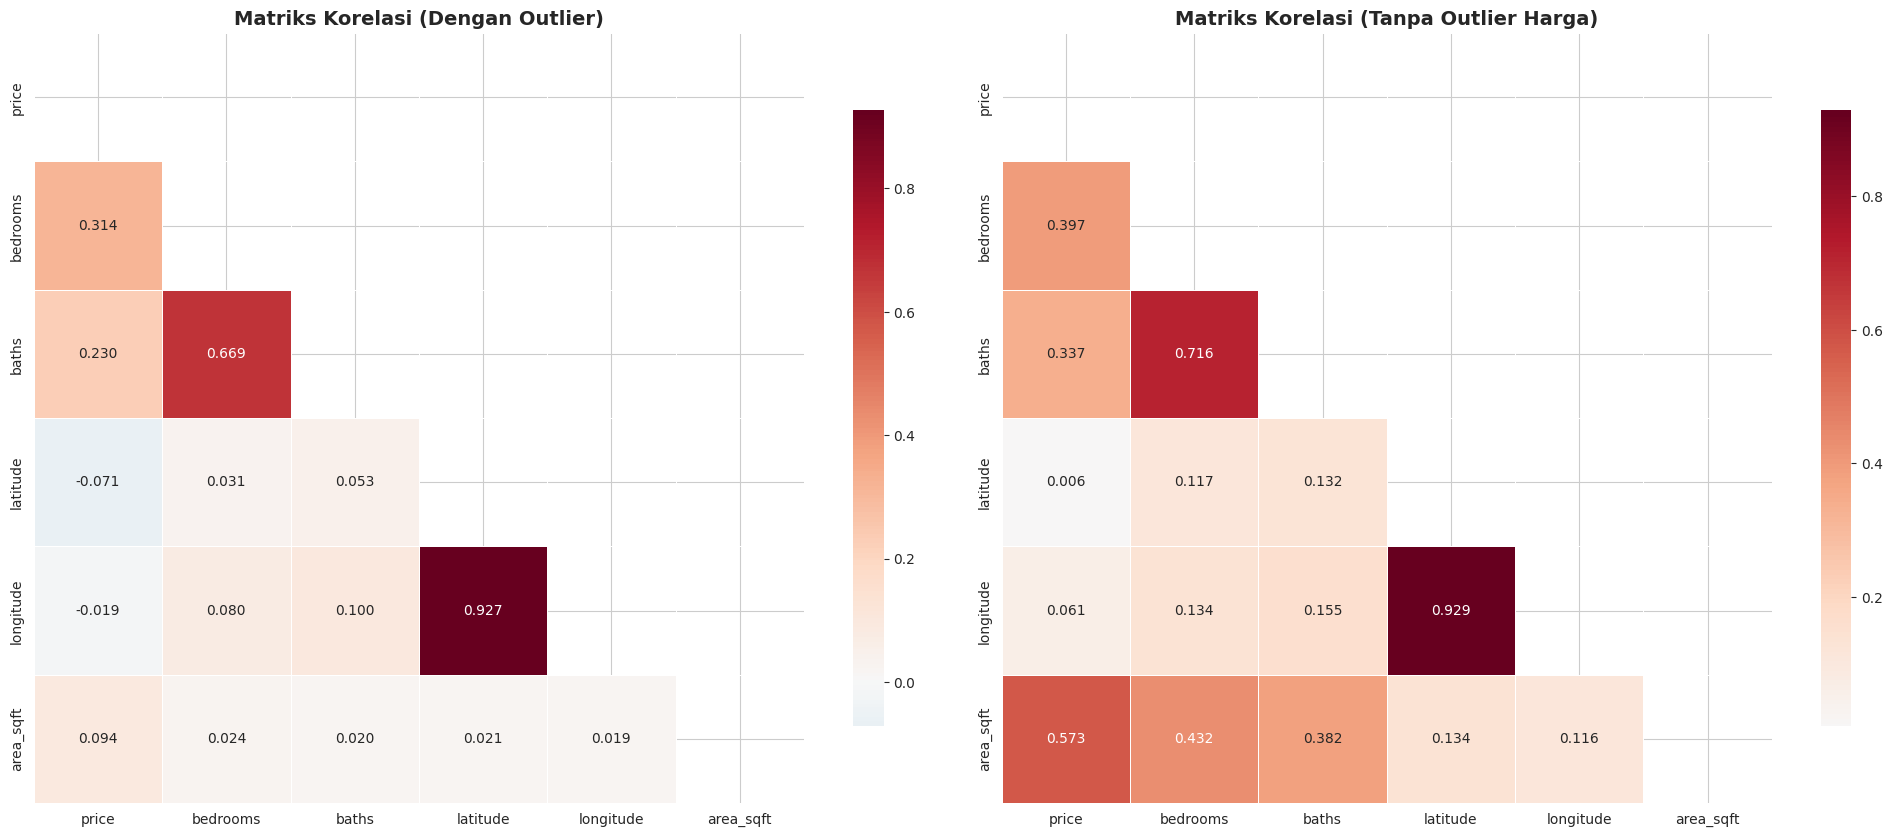

In [173]:
# MATRIKS KORELASI

# Hitung matriks korelasi kedua versi
corr_matrix = df_numeric.corr()

# Siapkan canvas subplots: 1 baris, 2 kolom
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask untuk segitiga atas

# --- PLOT 1: DENGAN OUTLIER (Sisi Kiri -> axes[0]) ---

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.3f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            mask=mask,
            cbar_kws={"shrink": 0.8},
            ax=axes[0])  # Diarahkan ke kolom pertama
axes[0].set_title('Matriks Korelasi (Dengan Outlier)', fontsize=14, fontweight='bold')


# --- PLOT 2: TANPA OUTLIER (Sisi Kanan -> axes[1]) ---
if len(df_no_outliers) > 1000:
    corr_matrix_clean = df_no_outliers.corr()

    sns.heatmap(corr_matrix_clean,
                annot=True,
                fmt='.3f',
                cmap='RdBu_r',
                center=0,
                square=True,
                linewidths=0.5,
                mask=mask,
                cbar_kws={"shrink": 0.8},
                ax=axes[1])  # Diarahkan ke kolom kedua
    axes[1].set_title('Matriks Korelasi (Tanpa Outlier Harga)', fontsize=14, fontweight='bold')
else:
    # Jika data terlalu sedikit, kosongkan axis kanan dan beri teks peringatan
    axes[1].text(0.5, 0.5, "Data terlalu sedikit\nsetelah filter outlier.", ha='center', va='center', fontsize=14, color='red')
    axes[1].axis('off') # Sembunyikan garis grafik jika kosong

# Atur tata letak agar tidak saling bertabrakan dan tampilkan
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


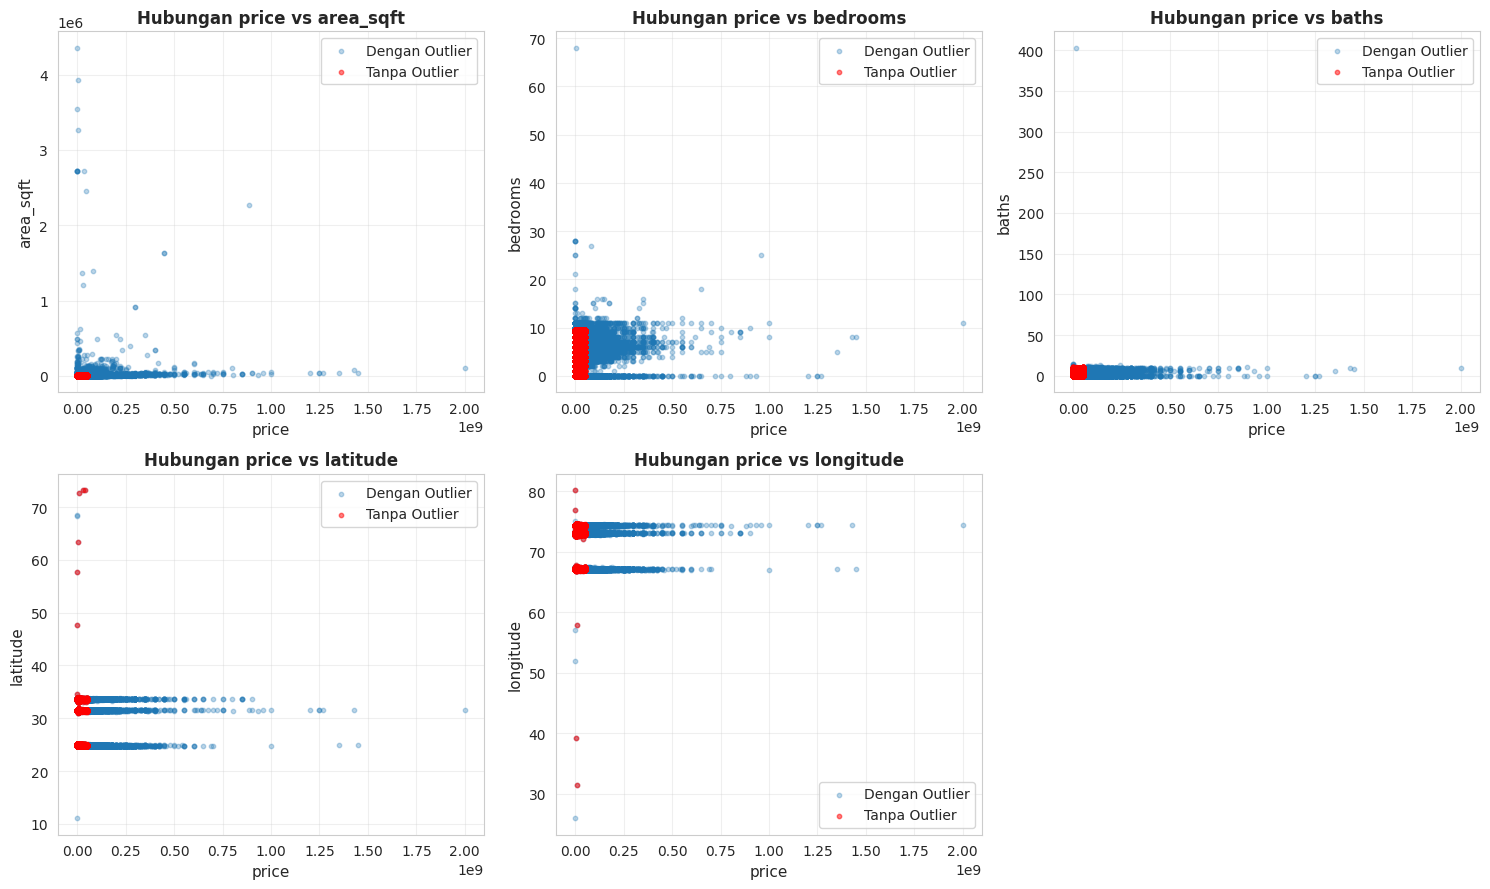

In [174]:
# VISUALISASI SCATTER PLOT (HUBUNGAN PASANGAN VARIABEL - 2 BARIS)

# Pilih pasangan variabel yang paling relevan
pairs = []
if 'area_sqft' in df_numeric.columns:
    pairs = [('price', 'area_sqft'), ('price', 'bedrooms'), ('price', 'baths'), ('price', 'latitude'), ('price', 'longitude')]
else:
    pairs = [('price', 'bedrooms'), ('price', 'baths')]



# Tentukan jumlah kolom berdasarkan pasangan data
n_cols = 3
n_rows = (len(pairs) + n_cols - 1) // n_cols  # Menghitung baris secara dinamis (akan jadi 2 baris)



# Set figsize: lebar disesuaikan jumlah kolom, tinggi disesuaikan jumlah baris
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4.5 * n_rows))



# CRITICAL: Ratakan axes menjadi 1 dimensi supaya bisa di-loop dengan zip()
axes_flat = axes.flatten()

for i, (x, y) in enumerate(pairs):
    ax = axes_flat[i]

    # Scatter plot dengan outlier dibedakan
    ax.scatter(df_numeric[x], df_numeric[y], alpha=0.3, s=10, label='Dengan Outlier')
    if len(df_no_outliers) > 1000:
        ax.scatter(df_no_outliers[x], df_no_outliers[y], alpha=0.5, s=10, c='red', label='Tanpa Outlier')

    ax.set_xlabel(x, fontsize=11)
    ax.set_ylabel(y, fontsize=11)
    ax.set_title(f'Hubungan {x} vs {y}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)



# Sembunyikan sisa kotak/axis kosong jika jumlah plot tidak memenuhi baris terakhir (misal plot ke-6 kosong)
for j in range(len(pairs), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

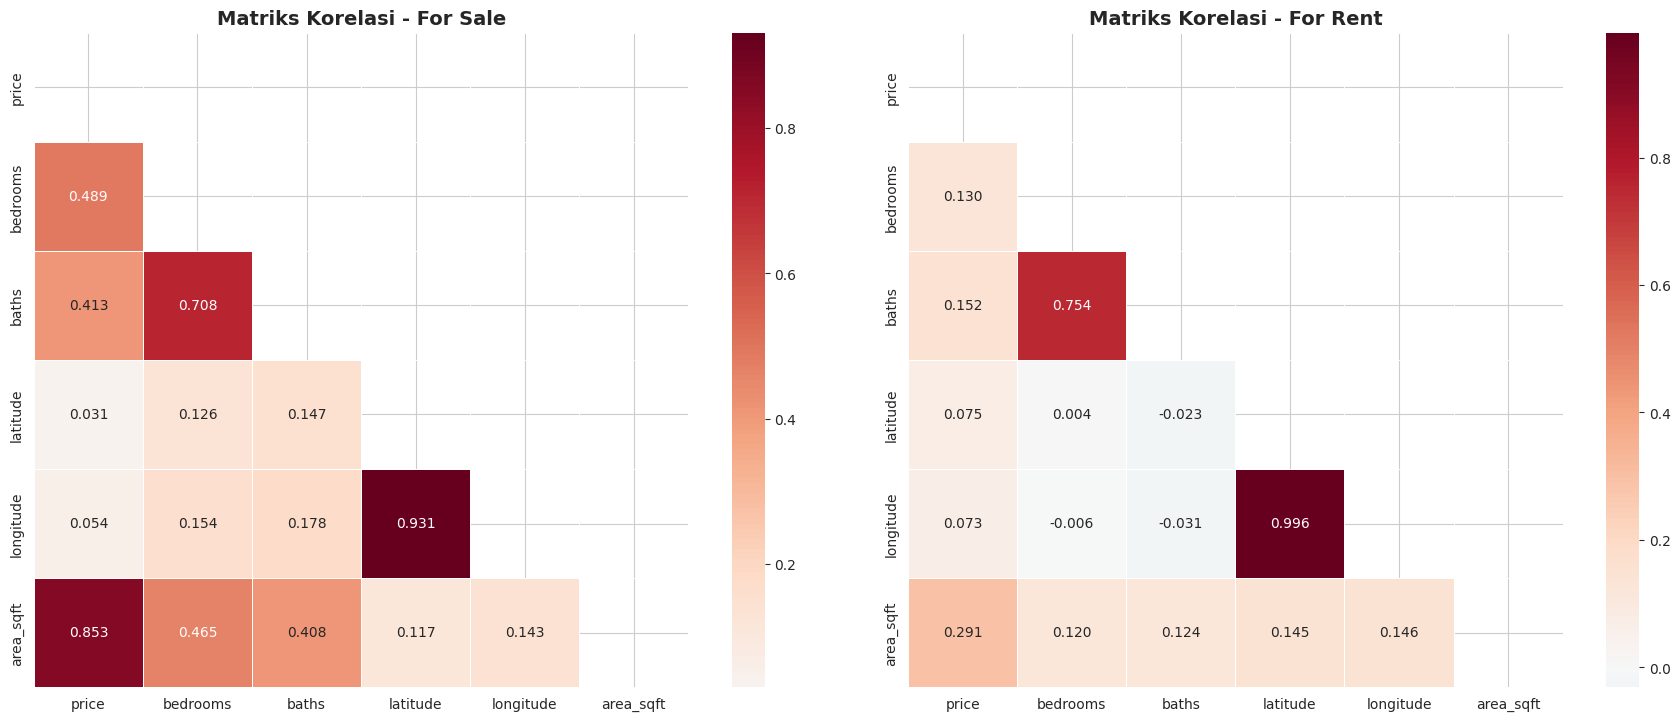

In [175]:
# 6. KORELASI PER KATEGORI (Berdasarkan Purpose - BERSEBELAHAN)

if 'purpose' in df.columns and len(df_no_outliers) > 0:
    df_with_purpose = df_no_outliers.copy()
    df_with_purpose['purpose'] = df.loc[df_with_purpose.index, 'purpose']

    # PERBAIKAN: Sesuaikan string dengan isi unik dari kolom purpose dataset-mu
    purposes = ['For Sale', 'For Rent']


    # 1. Inisialisasi canvas subplots: 1 baris, 2 kolom
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))


    # 2. Gunakan enumerate untuk mengarahkan plot ke axes[i] yang sesuai
    for i, purpose_val in enumerate(purposes):
        df_purpose = df_with_purpose[df_with_purpose['purpose'] == purpose_val]

        if len(df_purpose) > 100:
            corr_purpose = df_purpose[available_cols].corr()

            # Buat mask korelasi spesifik untuk ukuran matriks ini
            mask = np.triu(np.ones_like(corr_purpose, dtype=bool))

            # Gambar heatmap ke axis yang spesifik
            sns.heatmap(corr_purpose,
                        annot=True,
                        fmt='.3f',
                        cmap='RdBu_r',
                        center=0,
                        square=True,
                        linewidths=0.5,
                        mask=mask,   # Menggunakan mask segitiga agar rapi
                        ax=axes[i])

            axes[i].set_title(f'Matriks Korelasi - {purpose_val}', fontsize=14, fontweight='bold')
        else:
            axes[i].text(0.5, 0.5, f"Data {purpose_val} terlalu sedikit\n(n={len(df_purpose)}).", ha='center', va='center', fontsize=12, color='red')

            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

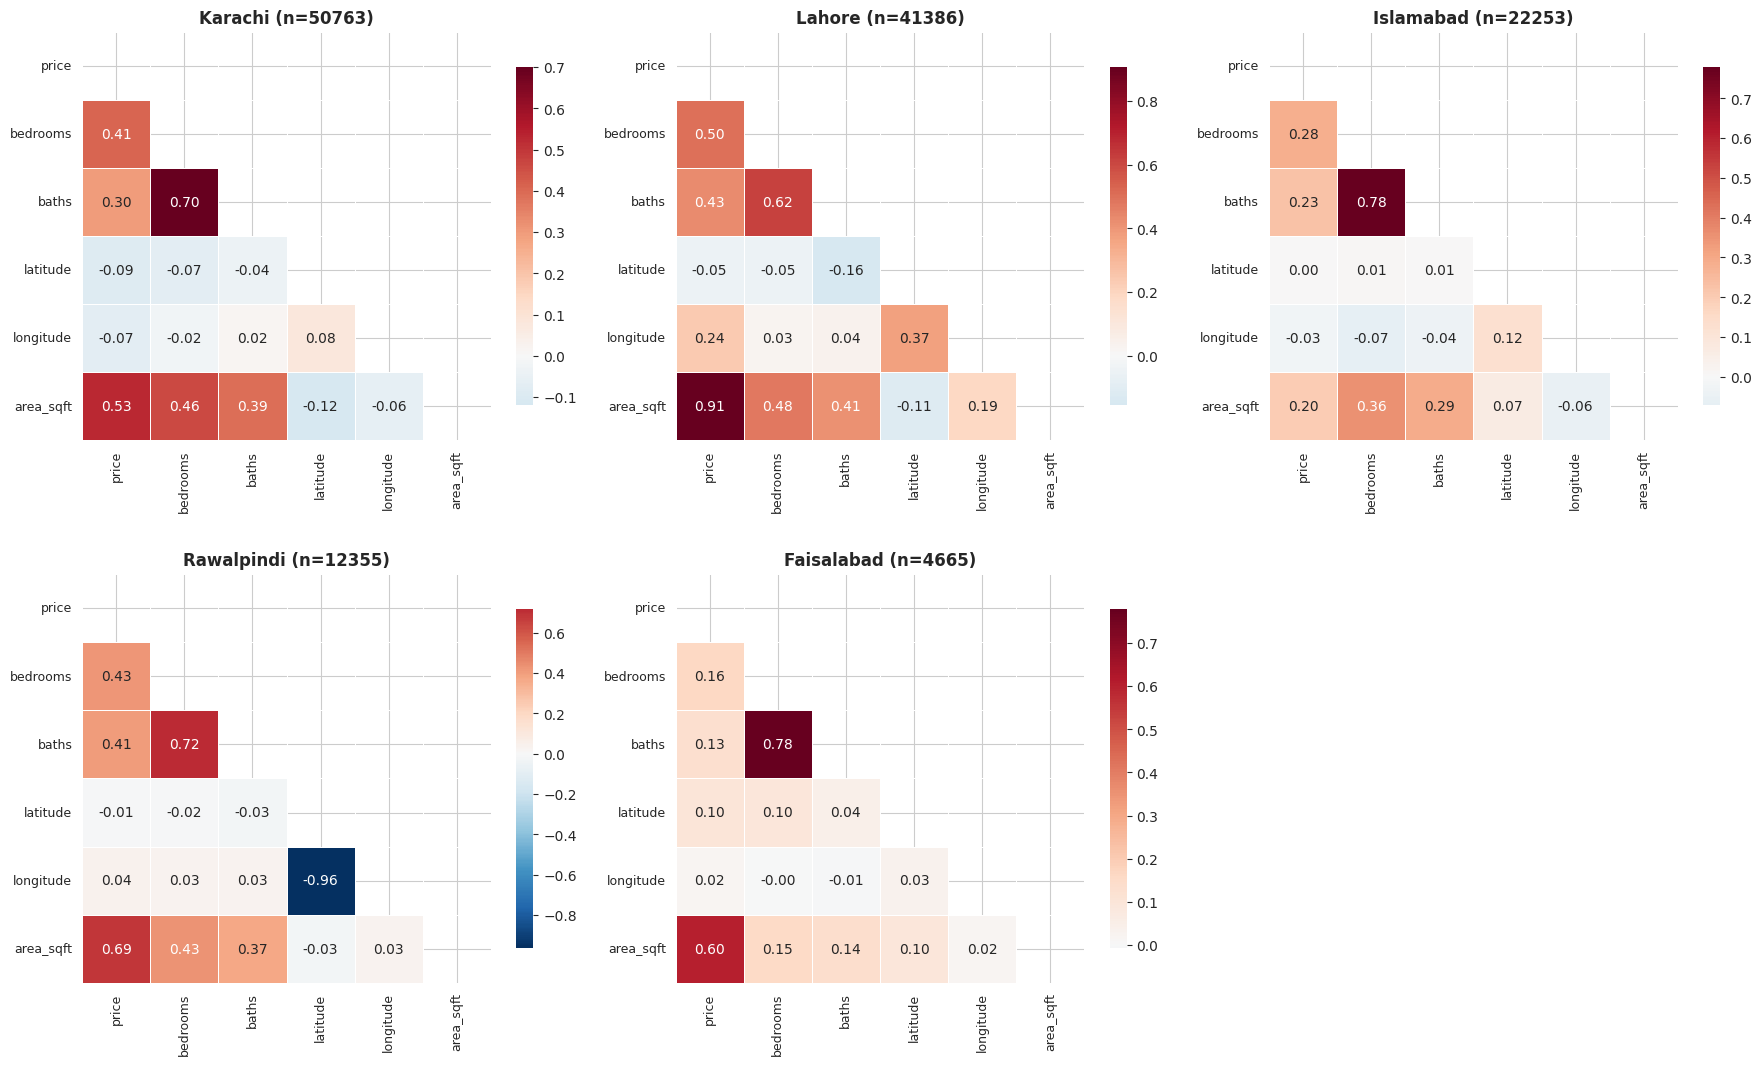

In [176]:
# 7. KORELASI PER KOTA (BONUS: Kota Terbesar - GRID HEATMAP)

if 'city' in df.columns and len(df_no_outliers) > 1000:
    top_cities = df['city'].value_counts().head(5).index
    df_with_city = df_no_outliers.copy()
    df_with_city['city'] = df.loc[df_with_city.index, 'city']

    # 1. Atur layout grid: 2 baris, 3 kolom (maksimal 6 slot untuk 5 kota)
    n_cols = 3
    n_rows = 2
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 11))

    # Ratakan axes menjadi 1 dimensi agar mudah di-loop
    axes_flat = axes.flatten()

    # 2. Loop tiap kota dan pasang heatmap ke axis masing-masing
    for i, city in enumerate(top_cities):
        df_city = df_with_city[df_with_city['city'] == city]
        ax = axes_flat[i]

        if len(df_city) > 50 and len(available_cols) >= 2:
            corr_city = df_city[available_cols].corr()

            # Buat mask segitiga atas agar tampilan heatmap bersih
            mask = np.triu(np.ones_like(corr_city, dtype=bool))

            # Gambar Heatmap
            sns.heatmap(corr_city,
                        annot=True,
                        fmt='.2f', # Menggunakan 2 desimal agar pas di kotak kecil
                        cmap='RdBu_r',
                        center=0,
                        square=True,
                        linewidths=0.5,
                        mask=mask,
                        cbar_kws={"shrink": 0.7},
                        ax=ax)

            ax.set_title(f'{city} (n={len(df_city)})', fontsize=12, fontweight='bold')
            ax.tick_params(labelsize=9) # Perkecil ukuran label text variabel
        else:
            ax.text(0.5, 0.5, f"⚠️ Data {city} tidak cukup", ha='center', va='center')
            ax.axis('off')

    # 3. Hapus slot ke-6 (indeks ke-5) yang kosong di pojok kanan bawah
    for j in range(len(top_cities), len(axes_flat)):
        fig.delaxes(axes_flat[j])

    # 4. Sesuaikan layout dan tampilkan
    plt.tight_layout()
    plt.show()

| Nilai r | Interpretasi |
|---------|--------------|
| 0.90 - 1.00 | Korelasi sangat kuat (positif) |
| 0.70 - 0.89 | Korelasi kuat (positif) |
| 0.50 - 0.69 | Korelasi sedang (positif) |
| 0.30 - 0.49 | Korelasi lemah (positif) |
| 0.00 - 0.29 | Korelasi sangat lemah / tidak berkorelasi |
| (-0.30) - (-0.01) | Korelasi negatif lemah |
| (-0.50) - (-0.31) | Korelasi negatif sedang |
| (-0.70) - (-0.51) | Korelasi negatif kuat |
| (-1.00) - (-0.71) | Korelasi negatif sangat kuat |

**Yang perlu diperhatikan dari hasil di atas:**

1. **Korelasi price vs bedrooms** → seberapa kuat hubungan jumlah kamar dengan harga
2. **Korelasi price vs baths** → apakah kamar mandi lebih berpengaruh dari kamar tidur
3. **Korelasi price vs area_sqft** (jika ada) → apakah luas tanah/ bangunan sangat menentukan harga
4. **Perbedaan korelasi antara Sale vs Rent** → apakah faktor yang mempengaruhi harga berbeda
5. **Perbedaan antar kota** → apakah di Karachi, hubungan bedrooms dan harga berbeda dengan Lahore
"""))

## Geospatial

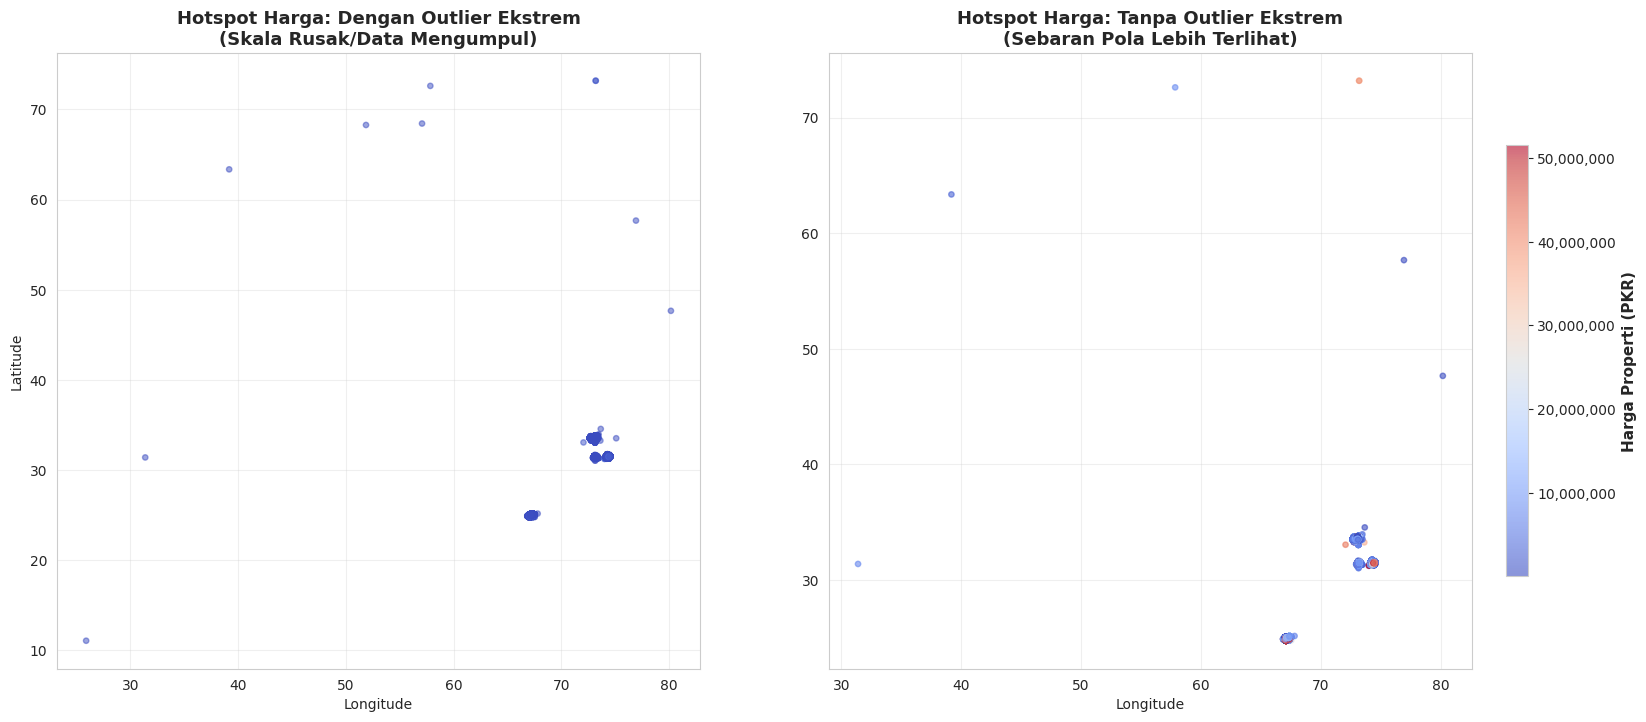

In [177]:
# PEMETAAN HARGA: DENGAN OUTLIER VS TANPA OUTLIER (BERSEBELAHAN)

if 'latitude' in df_numeric.columns and 'longitude' in df_numeric.columns:
    # Buat subplots berdampingan (1 baris, 2 kolom)
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 8))

    # --- PLOT KIRI: DENGAN OUTLIER ---
    scatter_with = axes[0].scatter(df_numeric['longitude'],
                                   df_numeric['latitude'],
                                   c=df_numeric['price'],
                                   cmap='coolwarm',
                                   alpha=0.5,
                                   s=15)
    axes[0].set_title('Hotspot Harga: Dengan Outlier Ekstrem\n(Skala Rusak/Data Mengumpul)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    axes[0].grid(True, alpha=0.3)

    # --- PLOT KANAN: TANPA OUTLIER ---
    scatter_without = axes[1].scatter(df_no_outliers['longitude'],
                                      df_no_outliers['latitude'],
                                      c=df_no_outliers['price'],
                                      cmap='coolwarm',
                                      alpha=0.6,
                                      s=15)
    axes[1].set_title('Hotspot Harga: Tanpa Outlier Ekstrem\n(Sebaran Pola Lebih Terlihat)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Longitude')
    axes[1].grid(True, alpha=0.3)

    # Tambahkan Colorbar di sisi paling kanan
    cbar = plt.colorbar(scatter_without, ax=axes, shrink=0.7, pad=0.02)
    cbar.set_label('Harga Properti (PKR)', fontsize=11, fontweight='bold')
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

    plt.show()

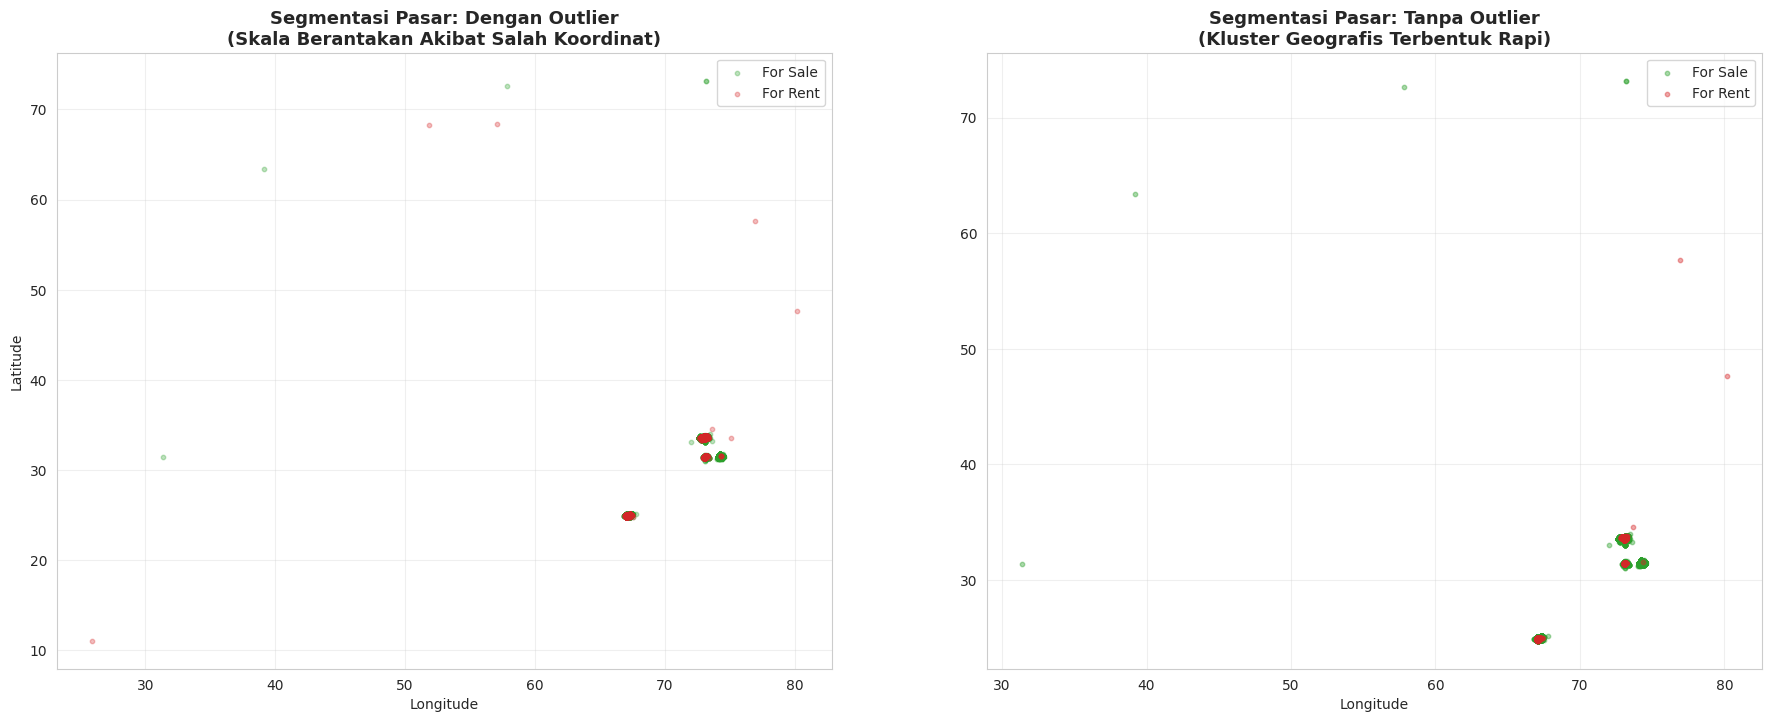

In [178]:
# SEGMENTASI PASAR SPASIAL: DENGAN OUTLIER VS TANPA OUTLIER (BERSEBELAHAN)

if 'purpose' in df.columns and 'latitude' in df_numeric.columns:
    # Penyiapan Data Dengan Outlier
    df_geo_with = df_numeric.copy()
    df_geo_with['purpose'] = df.loc[df_geo_with.index, 'purpose']

    # Penyiapan Data Tanpa Outlier
    df_geo_without = df_no_outliers.copy()
    df_geo_without['purpose'] = df.loc[df_geo_without.index, 'purpose']

    # Buat subplots berdampingan (1 baris, 2 kolom)
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 8))
    colors = {'For Sale': '#2ca02c', 'For Rent': '#d62728'}

    # --- PLOT KIRI: DENGAN OUTLIER ---
    for purpose_val, color in colors.items():
        sub_with = df_geo_with[df_geo_with['purpose'] == purpose_val]
        axes[0].scatter(sub_with['longitude'], sub_with['latitude'],
                        c=color, alpha=0.3, s=10, label=purpose_val)
    axes[0].set_title('Segmentasi Pasar: Dengan Outlier\n(Skala Berantakan Akibat Salah Koordinat)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # --- PLOT KANAN: TANPA OUTLIER ---
    for purpose_val, color in colors.items():
        sub_without = df_geo_without[df_geo_without['purpose'] == purpose_val]
        axes[1].scatter(sub_without['longitude'], sub_without['latitude'],
                        c=color, alpha=0.4, s=10, label=purpose_val)
    axes[1].set_title('Segmentasi Pasar: Tanpa Outlier\n(Kluster Geografis Terbentuk Rapi)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Longitude')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.show()

# Data Preprocessing

In [179]:
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131422 entries, 0 to 168445
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   price      131422 non-null  float64
 1   bedrooms   131422 non-null  float64
 2   baths      131422 non-null  float64
 3   latitude   131422 non-null  float64
 4   longitude  131422 non-null  float64
 5   area_sqft  131422 non-null  float64
dtypes: float64(6)
memory usage: 7.0 MB


In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   property_id    168446 non-null  int64         
 1   location_id    168446 non-null  int64         
 2   page_url       168446 non-null  object        
 3   property_type  168446 non-null  object        
 4   price          168446 non-null  int64         
 5   location       168446 non-null  object        
 6   city           168446 non-null  object        
 7   province_name  168446 non-null  object        
 8   latitude       168446 non-null  float64       
 9   longitude      168446 non-null  float64       
 10  baths          168446 non-null  int64         
 11  purpose        168446 non-null  object        
 12  bedrooms       168446 non-null  int64         
 13  date_added     168446 non-null  datetime64[ns]
 14  area_sqft      168446 non-null  float64       
dtype

In [181]:
# Menarik kembali kolom kategorikal ke data yang sudah bersih dari outlier
df_ready = df_no_outliers.copy()

df_ready['purpose'] = df.loc[df_ready.index, 'purpose']

df_ready['city'] = df.loc[df_ready.index, 'city']

df_ready['property_type'] = df.loc[df_ready.index, 'property_type']

In [182]:
df_ready.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131422 entries, 0 to 168445
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   price          131422 non-null  float64
 1   bedrooms       131422 non-null  float64
 2   baths          131422 non-null  float64
 3   latitude       131422 non-null  float64
 4   longitude      131422 non-null  float64
 5   area_sqft      131422 non-null  float64
 6   purpose        131422 non-null  object 
 7   city           131422 non-null  object 
 8   property_type  131422 non-null  object 
dtypes: float64(6), object(3)
memory usage: 10.0+ MB


In [183]:
df_ready.isna().sum()

,0
price,0
bedrooms,0
baths,0
latitude,0
longitude,0
area_sqft,0
purpose,0
city,0
property_type,0


# Feature Engineering

In [184]:
# Terapkan One-Hot Encoding
df_encoded = pd.get_dummies(df_ready, columns=['purpose', 'city', 'property_type'], drop_first=True)


# Ubah tipe data True/False hasil get_dummies menjadi angka 1/0 agar bisa dibaca matriks dari scratch
categorical_cols = df_encoded.select_dtypes(include=['bool']).columns

df_encoded[categorical_cols] = df_encoded[categorical_cols].astype(int)

In [185]:
# Tentukan Target dan Fitur
y = df_encoded['price'].values

# Hapus price dari X, serta koordinat jika tidak ingin digunakan dalam regresi dasar
X = df_encoded.drop(columns=['price', 'latitude', 'longitude']).values

In [186]:
# Fungsi scaling dari scratch
def standard_scaler(X_matrix):
    mean = np.mean(X_matrix, axis=0)
    std = np.std(X_matrix, axis=0)
    # Hindari pembagian dengan nol jika ada kolom yang std-nya 0
    std[std == 0] = 1
    X_scaled = (X_matrix - mean) / std
    return X_scaled, mean, std

# Jalankan scaling pada fitur X
X_scaled, X_mean, X_std = standard_scaler(X)

In [187]:
print("HASIL FEATURE ENGINEERING")
print(f"Jumlah Baris Data: {X_scaled.shape[0]}")
print(f"Jumlah Fitur (Kolom X setelah Encoding): {X_scaled.shape[1]}")
print(f"Bentuk Matriks X_scaled: {X_scaled.shape}")
print(f"Bentuk Array y (Target): {y.shape}")

HASIL FEATURE ENGINEERING
Jumlah Baris Data: 131422
Jumlah Fitur (Kolom X setelah Encoding): 14
Bentuk Matriks X_scaled: (131422, 14)
Bentuk Array y (Target): (131422,)


# Data Splitting

In [188]:
# Melakukan splitting dengan rasio 80% Train dan 20% Test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#
# CEK UKURAN MATRIKS SETELAH SPLITTING
print("TAHAPAN DATA SPLITTING FINISHED")
print(f"Total Data Awal     : {X_scaled.shape[0]} baris")

print("----------------------------------------")

print(f"X_train (Fitur Latih) : {X_train.shape} -> 80% data")
print(f"y_train (Target Latih): {y_train.shape}")

print("----------------------------------------")

print(f"X_test  (Fitur Uji)   : {X_test.shape} -> 20% data")
print(f"y_test  (Target Uji)  : {y_test.shape}")

TAHAPAN DATA SPLITTING FINISHED
Total Data Awal     : 131422 baris
----------------------------------------
X_train (Fitur Latih) : (105137, 14) -> 80% data
y_train (Target Latih): (105137,)
----------------------------------------
X_test  (Fitur Uji)   : (26285, 14) -> 20% data
y_test  (Target Uji)  : (26285,)


# Modeling

In [189]:
class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # 1. Inisialisasi awal weights dengan angka nol dan bias dengan nol
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        # 2. Perulangan Gradient Descent (Proses Training)
        for epoch in range(self.epochs):
            # Hitung prediksi saat ini (Hypothesis)
            # y = w.x+b
            y_predicted = np.dot(X, self.weights) + self.bias

            # Hitung nilai Error saat ini (Cost Function - MSE)
            loss = (1 / (2 * n_samples)) * np.sum((y_predicted - y) ** 2)
            self.loss_history.append(loss)

            # Hitung Turunan Parsial (Gradients)
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Perbarui parameter weights dan bias (Update Rule)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Cetak perkembangan loss setiap 100 epoch
            if (epoch + 1) % 100 == 0 or epoch == 0:
                print(f"Epoch {epoch+1}/{self.epochs} -> Loss (MSE): {loss:,.2f}")

    def predict(self, X):
        # Fungsi untuk memprediksi data baru setelah model selesai dilatih
        return np.dot(X, self.weights) + self.bias




# EKSEKUSI TRAINING MODEL
print("MEMULAI PROSES TRAINING LINEAR REGRESSION FROM SCRATCH")


# Inisialisasi model dengan learning rate 0.05 agar konvergen cepat dan stabil
model_scratch = LinearRegressionFromScratch(learning_rate=0.05, epochs=1000)


# Jalankan proses training menggunakan data X_train dan y_train hasil splitting
model_scratch.fit(X_train, y_train)


print("\nTRAINING SELESAI")
print(f"Final Bias (Intercept b) : {model_scratch.bias:,.2f}")
print(f"Jumlah Weights (w)       : {len(model_scratch.weights)} koefisien berhasil terbentuk.")

MEMULAI PROSES TRAINING LINEAR REGRESSION FROM SCRATCH
Epoch 1/1000 -> Loss (MSE): 277,263,735,990,621.75
Epoch 100/1000 -> Loss (MSE): 31,293,564,848,375.34
Epoch 200/1000 -> Loss (MSE): 30,752,782,923,339.61
Epoch 300/1000 -> Loss (MSE): 30,727,602,288,462.38
Epoch 400/1000 -> Loss (MSE): 30,712,016,294,675.69
Epoch 500/1000 -> Loss (MSE): 30,699,842,727,429.75
Epoch 600/1000 -> Loss (MSE): 30,690,015,605,853.04
Epoch 700/1000 -> Loss (MSE): 30,681,878,713,657.80
Epoch 800/1000 -> Loss (MSE): 30,675,000,876,738.41
Epoch 900/1000 -> Loss (MSE): 30,669,092,577,735.46
Epoch 1000/1000 -> Loss (MSE): 30,663,954,584,957.39

TRAINING SELESAI
Final Bias (Intercept b) : 17,588,084.74
Jumlah Weights (w)       : 14 koefisien berhasil terbentuk.


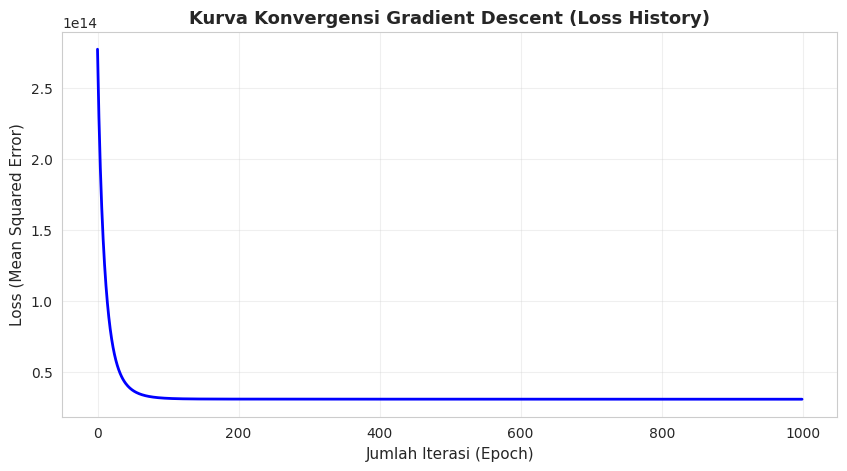

In [190]:
# VISUALISASI KURVA PEMBELAJARAN (LOSS HISTORY)
plt.figure(figsize=(10, 5))
plt.plot(model_scratch.loss_history, color='blue', lw=2)
plt.title('Kurva Konvergensi Gradient Descent (Loss History)', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Iterasi (Epoch)', fontsize=11)
plt.ylabel('Loss (Mean Squared Error)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Model Evaluation

HASIL EVALUASI MODEL (DATA TESTING)
Mean Absolute Error (MAE) : PKR 5,459,268.83
Root Mean Squared Error (RMSE): PKR 7,860,393.14
R² Score (Akurasi Model)   : 0.7450 (74.50%)


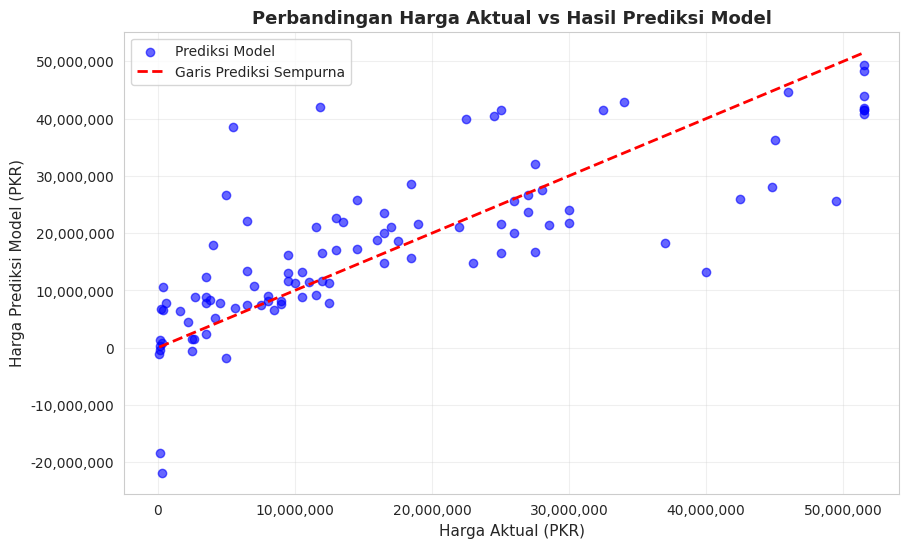

In [191]:
# 1. PREDIKSI DATA TESTING
# Lakukan prediksi pada data X_test menggunakan model
y_pred = model_scratch.predict(X_test)



# 2. HITUNG METRIK EVALUASI DARI SCRATCH
# Rumus MAE: (1/n) * Σ|y_asli - y_prediksi|
mae = np.mean(np.abs(y_test - y_pred))
# Rumus MSE & RMSE: √( (1/n) * Σ(y_asli - y_prediksi)² )
mse_test = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse_test)
# Rumus R² Score: 1 - (SS_res / SS_tot)
ss_residual = np.sum((y_test - y_pred) ** 2)
ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
r2_score = 1 - (ss_residual / ss_total)



# 3. CETAK HASIL EVALUASI
print("HASIL EVALUASI MODEL (DATA TESTING)")
print(f"Mean Absolute Error (MAE) : PKR {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): PKR {rmse:,.2f}")
print(f"R² Score (Akurasi Model)   : {r2_score:.4f} ({r2_score*100:.2f}%)")



# 4. VISUALISASI AKTUAL VS PREDIKSI
plt.figure(figsize=(10, 6))
# Ambil sampel 100 data saja agar grafik scatter tidak terlalu padat bergumpal
sample_idx = np.random.choice(len(y_test), size=100, replace=False)
plt.scatter(y_test[sample_idx], y_pred[sample_idx], color='blue', alpha=0.6, label='Prediksi Model')
# Garis diagonal sempurna (Jika aktual == prediksi)
perfect_line = [min(y_test[sample_idx]), max(y_test[sample_idx])]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', lw=2, label='Garis Prediksi Sempurna')
plt.title('Perbandingan Harga Aktual vs Hasil Prediksi Model', fontsize=13, fontweight='bold')
plt.xlabel('Harga Aktual (PKR)', fontsize=11)
plt.ylabel('Harga Prediksi Model (PKR)', fontsize=11)
# Format mata uang pada sumbu grafik
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))



plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Residual Analysis

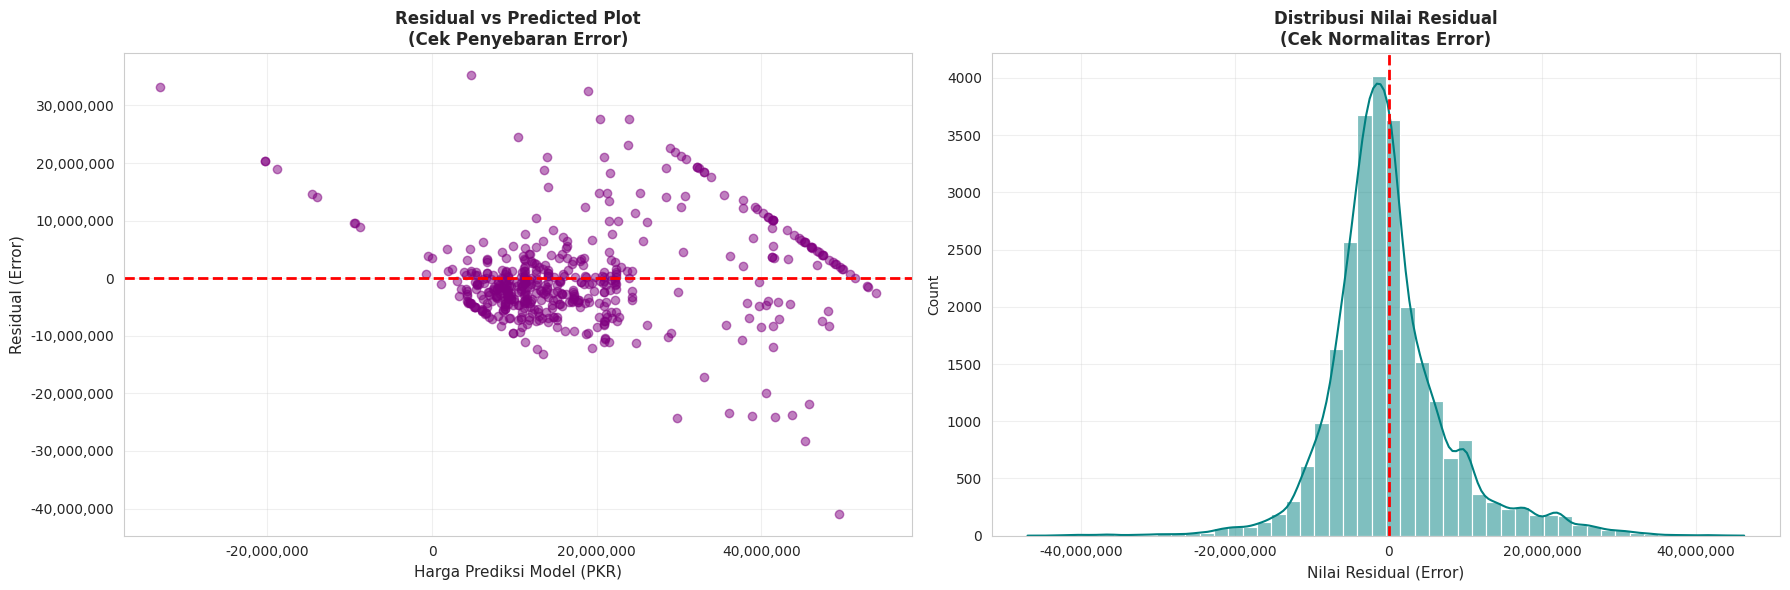

In [192]:
# 1. HITUNG RESIDUAL (ERROR = AKTUAL - PREDIKSI)
residuals = y_test - y_pred


# 2. VISUALISASI RESIDUAL ANALYSIS (2 GRAFIK BERSAMPINGAN)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))


# --- GRAFIK KIRI: RESIDUAL PLOT (Mengecek Homoskedastisitas) ---
# Ambil sampel 500 titik saja agar grafik tidak terlalu padat bergumpal
sample_res_idx = np.random.choice(len(residuals), size=500, replace=False)

axes[0].scatter(y_pred[sample_res_idx], residuals[sample_res_idx], color='purple', alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0].set_title('Residual vs Predicted Plot\n(Cek Penyebaran Error)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Harga Prediksi Model (PKR)', fontsize=11)
axes[0].set_ylabel('Residual (Error)', fontsize=11)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[0].grid(True, alpha=0.3)



# --- GRAFIK KANAN: HISTOGRAM RESIDUAL (Mengecek Normalitas Error) ---
sns.histplot(residuals, kde=True, ax=axes[1], color='teal', bins=50)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_title('Distribusi Nilai Residual\n(Cek Normalitas Error)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nilai Residual (Error)', fontsize=11)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance Interpretation

TABEL BOBOT KOEFISIEN FITUR


,Fitur,Weights
0,area_sqft,1.245620e+07
1,purpose_For Sale,1.065353e+07
2,city_Karachi,2.149986e+06
3,property_type_House,2.030142e+06
4,bedrooms,1.260963e+06
5,city_Islamabad,8.494352e+05
6,city_Rawalpindi,-5.616790e+05
7,property_type_Flat,3.518059e+05
8,baths,2.156965e+05
9,city_Lahore,2.135943e+05


/tmp/ipykernel_794/4089168062.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Weights', y='Fitur', palette=colors_importance)


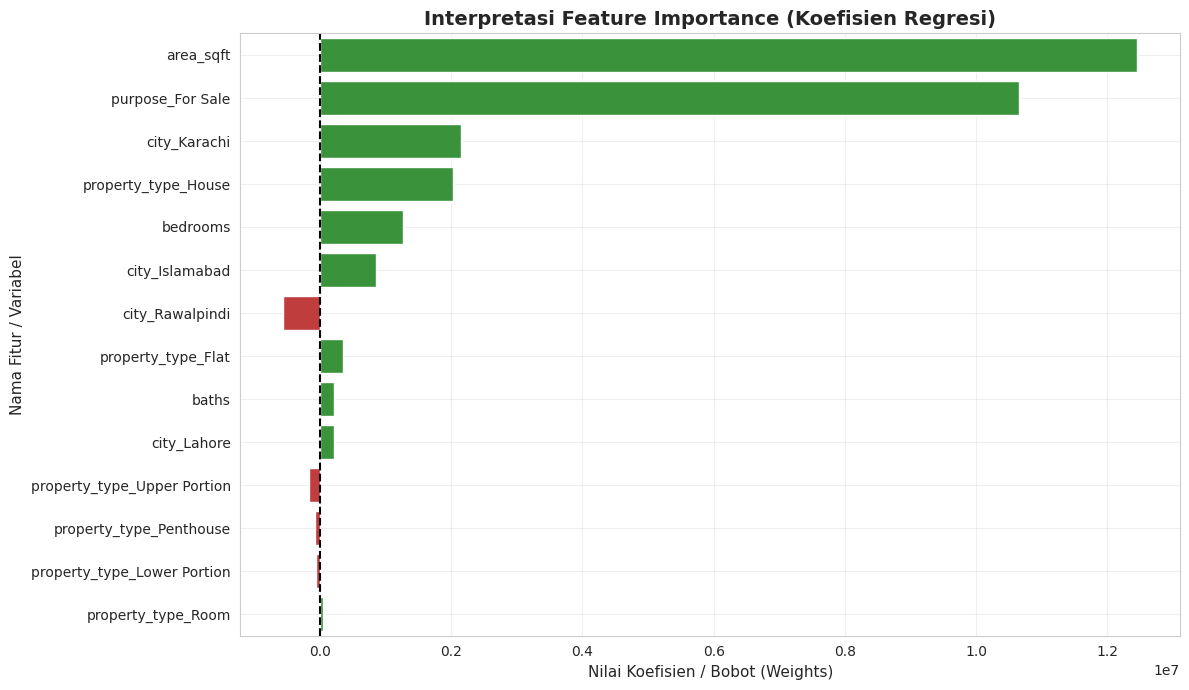

In [193]:
# 1. AMBIL KATA KUNCI NAMA FITUR SETELAH ENCODING
# Ambil daftar nama kolom asli dari df_encoded (kecuali kolom target dan yang di-drop)
feature_names = df_encoded.drop(columns=['price', 'latitude', 'longitude']).columns

# Ambil nilai weights dari model scratch buatanmu
weights_value = model_scratch.weights




# 2. BUAT DATAFRAME UNTUK MERANGKUM BOBOT FITUR
df_importance = pd.DataFrame({
    'Fitur': feature_names,
    'Weights': weights_value,
    'Abs_Weights': np.abs(weights_value) # Untuk pengurutan dari yang paling berpengaruh
})

# Urutkan berdasarkan nilai absolut terbesar ke terkecil
df_importance = df_importance.sort_values(by='Abs_Weights', ascending=False).reset_index(drop=True)

print("TABEL BOBOT KOEFISIEN FITUR")
display(df_importance[['Fitur', 'Weights']])




# 3. VISUALISASI GRAFIK BATANG FEATURE IMPORTANCE
plt.figure(figsize=(12, 7))

# Tentukan warna: Hijau untuk koefisien positif, Merah untuk koefisien negatif
colors_importance = ['#2ca02c' if w >= 0 else '#d62728' for w in df_importance['Weights']]

sns.barplot(data=df_importance, x='Weights', y='Fitur', palette=colors_importance)
plt.axvline(x=0, color='black', linestyle='--', lw=1.5)

plt.title('Interpretasi Feature Importance (Koefisien Regresi)', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Koefisien / Bobot (Weights)', fontsize=11)
plt.ylabel('Nama Fitur / Variabel', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparison with SKLEARN

In [194]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. INBOUND & TRAINING MODEL SKLEARN
model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)

# Prediksi menggunakan data testing
y_pred_sklearn = model_sklearn.predict(X_test)




# 2. HITUNG METRIK EVALUASI SKLEARN
mae_sk = mean_absolute_error(y_test, y_pred_sklearn)
rmse_sk = np.sqrt(mean_squared_error(y_test, y_pred_sklearn))
r2_sk = r2_score(y_test, y_pred_sklearn)




# 3. KOMPARASI HASIL: SCRATCH VS SKLEARN
print("PERBANDINGAN PERFORMA MODEL")
print(f"Metrik   | Model From Scratch   | Model Scikit-Learn")
print(f"--------------------------------------------------")
# Ambil nilai R2 dari tahap evaluasi sebelumnya (atau hitung kembali dari y_pred buatanmu)
r2_scratch = 1 - (np.sum((y_test - y_pred) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))
mae_scratch = np.mean(np.abs(y_test - y_pred))

print(f"R² Score | {r2_scratch*100:.2f}%               | {r2_sk*100:.2f}%")
print(f"MAE      | PKR {mae_scratch:,.2f}       | PKR {mae_sk:,.2f}")
print(f"Bias (b) | {model_scratch.bias:,.2f}        | {model_sklearn.intercept_:,.2f}")




# 4. KOMPARASI BOBOT FITUR (WEIGHTS)
df_compare_weights = pd.DataFrame({
    'Nama Fitur': feature_names,
    'Weights (Scratch)': model_scratch.weights,
    'Weights (Sklearn)': model_sklearn.coef_
})

print("\nPERBANDINGAN BOBOT NILAI KOEFISIEN (X)")
display(df_compare_weights.round(2))

PERBANDINGAN PERFORMA MODEL
Metrik   | Model From Scratch   | Model Scikit-Learn
--------------------------------------------------
R² Score | 74.50%               | 74.54%
MAE      | PKR 5,459,268.83       | PKR 5,455,669.13
Bias (b) | 17,588,084.74        | 17,587,660.11

PERBANDINGAN BOBOT NILAI KOEFISIEN (X)


,Nama Fitur,Weights (Scratch),Weights (Sklearn)
0,bedrooms,1260962.58,1217519.81
1,baths,215696.55,203071.46
2,area_sqft,12456196.29,12529562.05
3,purpose_For Sale,10653529.29,10684076.29
4,city_Islamabad,849435.22,940627.57
5,city_Karachi,2149986.01,2244943.85
6,city_Lahore,213594.30,320840.95
7,city_Rawalpindi,-561679.04,-494073.42
8,property_type_Flat,351805.90,2146475.23
9,property_type_House,2030142.44,3937783.24


# Prediksi

In [195]:
def prediksi_harga_properti(purpose, city, property_type, bedrooms, baths, area_sqft):
    # 1. Buat DataFrame kosong dengan struktur kolom yang persis sama dengan X saat training
    # feature_names diambil dari tahap feature engineering sebelumnya
    df_input = pd.DataFrame(columns=feature_names)
    df_input.loc[0] = 0 # Inisialisasi awal semua kolom dengan angka 0


    # 2. Masukkan nilai fitur numerik dasar
    df_input['bedrooms'] = bedrooms
    df_input['baths'] = baths
    df_input['area_sqft'] = area_sqft


    # 3. Lakukan pemetaan biner untuk One-Hot Encoding (drop_first=True)
    # Jika kategori yang dipilih adalah baseline (yang di-drop saat get_dummies),
    # kolomnya sengaja dibiarkan bernilai 0.
    col_purpose = f"purpose_{purpose}"
    if col_purpose in df_input.columns:
        df_input[col_purpose] = 1

    col_city = f"city_{city}"
    if col_city in df_input.columns:
        df_input[col_city] = 1

    col_type = f"property_type_{property_type}"
    if col_type in df_input.columns:
        df_input[col_type] = 1

    # Convert ke NumPy array matriks X_user
    X_user = df_input.values



    # 4. Terapkan Standardisasi menggunakan X_mean dan X_std historis data training
    # PERINGATAN: Jangan menghitung mean/std baru dari data input tunggal ini!
    X_user_scaled = (X_user - X_mean) / X_std



    # 5. Hitung Prediksi menggunakan model dari scratch
    harga_prediksi = model_scratch.predict(X_user_scaled)[0]


    # Batasi agar prediksi tidak bernilai minus akibat sifat garis linear regression
    if harga_prediksi < 0:
        harga_prediksi = 0

    # 6. Tampilkan Hasil Cetak
    print("==================================================")
    print("        HASIL ESTIMASI HARGA PROPERTI             ")
    print("==================================================")
    print(f" Status Kontrak : {purpose}")
    print(f" Lokasi Kota    : {city}")
    print(f" Tipe Properti  : {property_type}")
    print(f" Spesifikasi    : {int(bedrooms)} kamar tidur | {int(baths)} kamar mandi")
    print(f" Luas Bangunan  : {area_sqft:,.0f} sqft")
    print("--------------------------------------------------")
    print(f" ESTIMASI HARGA : PKR {harga_prediksi:,.2f}")
    print("==================================================")

    return harga_prediksi

In [196]:
# CONTOH 1: Ingin membeli Rumah di Lahore dengan 3 Kamar Tidur
harga_1 = prediksi_harga_properti(
    purpose='For Sale',
    city='Lahore',
    property_type='House',
    bedrooms=3,
    baths=3,
    area_sqft=1125
)

# CONTOH 2: Ingin menyewa Apartemen/Flat di Karachi dengan 2 Kamar Tidur
harga_2 = prediksi_harga_properti(
    purpose='For Rent',
    city='Karachi',
    property_type='Flat',
    bedrooms=2,
    baths=2,
    area_sqft=900
)

        HASIL ESTIMASI HARGA PROPERTI             
 Status Kontrak : For Sale
 Lokasi Kota    : Lahore
 Tipe Properti  : House
 Spesifikasi    : 3 kamar tidur | 3 kamar mandi
 Luas Bangunan  : 1,125 sqft
--------------------------------------------------
 ESTIMASI HARGA : PKR 9,564,142.96
        HASIL ESTIMASI HARGA PROPERTI             
 Status Kontrak : For Rent
 Lokasi Kota    : Karachi
 Tipe Properti  : Flat
 Spesifikasi    : 2 kamar tidur | 2 kamar mandi
 Luas Bangunan  : 900 sqft
--------------------------------------------------
 ESTIMASI HARGA : PKR 0.00
